# Прикладные задачи и оценка качества предсказаний

Ноутбук интегрирует обученную сегментационную модель с прикладными задачами, производными
от воксельной разметки, и проводит количественный анализ её предсказаний на валидационной
подвыборке. Помимо точечных значений метрик качества вычисляются доверительные интервалы
методом бутстрэпа, выполняется декомпозиция ошибок сегментации по типам, оценивается
качество классификации присутствия структуры на срезах, точность детекции через
ограничивающий параллелепипед и согласованность предсказанных объёмов с эталонными.
Содержание следует структуре медицинского исследования: введению с клиническим контекстом,
описанию материалов и методов, результатам по задачам и обсуждению с клинической
интерпретацией.


## Введение

### Клинический контекст прикладных задач

Сегментация гиппокампа на МР-томографии редко является конечной целью исследования.
Клинически и научно значимыми являются производные характеристики, извлекаемые из
сегментационной маски: объём структуры, его соотношение с нормой и возрастной динамикой,
пространственное распределение атрофии между подобластями. Морфометрия гиппокампа
применяется как ранний биомаркер болезни Альцгеймера, в дифференциальной диагностике
височной эпилепсии и в оценке последствий травматических и психиатрических состояний
(Jack et al., 2010; Frisoni et al., 2010). Снижение объёма гиппокампа на 3–5 % в год
сопоставимо с темпами атрофии при болезни Альцгеймера, тогда как физиологическое старение
сопровождается потерей порядка 0.5 % в год.

Из этого вытекает требование к качеству автоматизированной сегментации: значимое
клиническое применение возможно только при ошибке оценки объёма, существенно меньшей
ожидаемых патологических изменений. Точечная Dice-метрика, общепринятая для оценки
сегментационных моделей, не отвечает на этот вопрос напрямую: модель с одинаковым
коэффициентом Дайса может давать систематически смещённые или несмещённые объёмные
оценки, и только специализированный анализ согласованности (диаграмма Бленда–Альтмана,
коэффициент согласия Линя) позволяет судить о её пригодности для морфометрии.

### От сегментации к прикладным задачам

Воксельная разметка является обобщённой формой представления, из которой механически
извлекаются метки задач меньшей размерности. Это позволяет одной сегментационной моделью
решать несколько содержательно различных задач без дополнительной аннотации:

* **Классификация** присутствия структуры на отдельном срезе — наличие хотя бы одного
  вокселя класса переднего плана на срезе соответствует положительной метке. Задача имеет
  практическое значение как фильтр, отсеивающий пустые срезы перед более ресурсоёмкой
  сегментацией или морфометрией.
* **Детекция** через ограничивающий параллелепипед — координаты минимального
  осепараллельного объёма, содержащего все воксели целевого класса. Применима для
  локализации области интереса перед более детальным анализом и для приближённой оценки
  пространственного расположения структуры.
* **Оценка физического объёма** — клинически значимая морфометрическая характеристика,
  используемая как биомаркер.

Анализ всех трёх прикладных задач строится на едином источнике — предсказаниях обученной
модели на валидационной выборке. Это демонстрирует методологическую экономию: расширение
сегментационной модели на прикладные задачи не требует ни перенастройки, ни дополнительной
разметки, а сводится к содержательно различной интерпретации одного и того же
предсказания.

### Цель ноутбука

Ноутбук решает следующие задачи:

1. Собрать предсказания обученной модели на всей валидационной подвыборке (52 объёма) и
   применить к ним стандартную постобработку методами классического компьютерного зрения.
2. Оценить эффект постобработки количественно с 95-процентными доверительными интервалами.
3. Охарактеризовать распределение метрик сегментации по объектам, выявить хвостовые
   случаи.
4. Выполнить декомпозицию ошибок сегментации по содержательным типам (ложноположительные,
   ложноотрицательные, путаница между подобластями), оценить связь ошибок с
   неопределённостью модели.
5. Оценить качество прикладных задач — классификации, детекции, оценки объёма — на той же
   валидационной выборке с применением стандартных для каждой задачи метрик.
6. Дать клиническую интерпретацию полученных результатов с привязкой к литературным
   референсам, в частности — норме объёма гиппокампа.
7. Зафиксировать ограничения текущей оценки и направления её развития.


## Материалы и методы

### Источник предсказаний

Предсказания получены применением обученной модели (чекпойнт `best.pt`, эпоха с наилучшим
валидационным коэффициентом Дайса — см. ноутбук 04) к валидационной подвыборке (52
исследования) с детерминированным препроцессингом из ноутбука 02. Валидационная
подвыборка восстанавливается тем же случайным разбиением с фиксированным seed, что
обеспечивает её идентичность той, на которой оценивалась модель в ходе обучения, и
исключает утечку информации обучения в оценку.

### Постобработка

К дискретизированному выходу модели применяются две операции классического компьютерного
зрения:

* **Сохранение наибольшей связной компоненты для каждого класса.** Устраняет
  изолированные ложноположительные фрагменты, не связанные с основной структурой. Эта
  операция согласуется с топологическим prior, установленным в разведочном анализе
  (раздел 6 ноутбука 01): целевая структура в каждой томограмме представлена единственной
  связной компонентой почти во всех масках.
* **Морфологическое замыкание (`closing`).** Применяется консервативно с радиусом 1 воксель
  для заполнения мелких внутренних полостей и сглаживания границ без существенного
  изменения объёма структуры.

### Метрики качества и их формулы

**Коэффициент Дайса и 95-й процентиль расстояния Хаусдорфа** для оценки сегментации
определены и применены в ноутбуке 03; их формулы здесь не повторяются. Метрики
вычисляются раздельно по классам переднего плана.

**3D IoU** для оценки детекции ограничивающим параллелепипедом — отношение объёма
пересечения двух осепараллельных параллелепипедов к объёму их объединения:

$$\mathrm{IoU}_\text{3D} = \frac{V(\hat{B} \cap B)}{V(\hat{B} \cup B)}$$

где $\hat{B}$, $B$ — предсказанный и эталонный параллелепипеды. Значение лежит в [0, 1].
В литературе по объектной детекции значение IoU ≥ 0.5 принято как порог успешной детекции,
≥ 0.7 — как порог уверенной локализации.

**Метрики бинарной классификации** для оценки задачи присутствия структуры на срезе:

$$\mathrm{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
$$\mathrm{Precision} = \frac{TP}{TP + FP},\quad \mathrm{Recall} = \frac{TP}{TP + FN},\quad F_1 = \frac{2 \cdot \mathrm{Precision} \cdot \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}}$$

Дополнительно используется максимум апостериорной вероятности класса переднего плана
(`max_prob`) как непрерывная мера уверенности; на её основе строятся **ROC-кривая**
(зависимость доли истинных от доли ложных положительных решений при варьировании порога) и
**PR-кривая** (precision как функция recall). При выраженном дисбалансе классов PR-кривая
информативнее ROC-кривой (Saito and Rehmsmeier, 2015).

**Коэффициент согласия Линя (Lin's CCC)** для оценки согласованности предсказанных и
истинных объёмов:

$$\mathrm{CCC} = \frac{2\,\rho\,\sigma_p\,\sigma_t}{\sigma_p^2 + \sigma_t^2 + (\mu_p - \mu_t)^2}$$

где $\mu_p, \mu_t$ — средние, $\sigma_p, \sigma_t$ — стандартные отклонения предсказанных и
истинных объёмов, $\rho$ — коэффициент корреляции Пирсона. Значение лежит в $[-1, 1]$;
интерпретация по McBride (2005): $> 0.99$ — почти идеальное согласие, $0.95$–$0.99$ —
сильное, $0.90$–$0.95$ — умеренное, ниже — слабое.

**Анализ Бленда–Альтмана** (Bland and Altman, 1986) — стандарт оценки согласованности двух
методов измерения в медицинской статистике. На горизонтальной оси откладывается среднее
двух измерений $\frac{p + t}{2}$, на вертикальной — их разность $p - t$. Систематическое
смещение (bias) оценивается средней разности; **границы согласия** (limits of agreement,
LoA) — $\text{bias} \pm 1.96 \cdot \text{SD}$, в пределах которых при нормальности
распределения разностей лежат 95 % измерений.

### Бутстрэп-оценка доверительных интервалов

Для основных метрик 95-процентные доверительные интервалы оцениваются методом перцентилей
бутстрэпа: 1000 ресэмплов с возвращением из исходной выборки объектов, расчёт метрики на
каждом ресэмпле, граничные перцентили 2.5 и 97.5 формируют интервал. Метод не предполагает
нормальности распределения метрики и устойчив к выбросам, что существенно для метрик с
ограниченной областью значений (Dice, IoU).


## Подготовка среды исполнения


In [1]:
!pip install -q "monai[nibabel,tqdm]==1.5.1" "nibabel==5.2.1" plotly matplotlib scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 50.8 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import sys
from pathlib import Path
from collections import Counter

PROJECT_ROOT = Path("/content/drive/MyDrive/hippocampus-segmentation")
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch

from monai.utils import set_determinism
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.transforms import Activations, AsDiscrete, Compose

from src.config import cfg
from src.data import load_data_dicts, split_data, get_val_transforms
from src.model import build_model
from src.postprocess import postprocess_mask
from src import downstream as ds
from src import visualization as viz

set_determinism(seed=cfg.seed)

# Единый стиль визуализаций (согласован с предшествующими ноутбуками).
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titlepad": 8,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.titlesize": 12.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
})

print(f"Задача            : {cfg.task_name}")
print(f"Число классов     : {cfg.num_classes}")
print(f"Метки переднего плана: {cfg.foreground_labels}")


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Задача            : Task04_Hippocampus
Число классов     : 3
Метки переднего плана: [1, 2]


## Результаты

### 1. Сбор предсказаний на валидационной подвыборке

Веса наилучшей модели (`best.pt`) загружаются, и для каждого валидационного исследования
вычисляются: дискретизированное предсказание, его постобработанная версия, карта
апостериорных вероятностей. Эти данные служат основой для всех последующих анализов.


In [4]:
device = torch.device(cfg.device)
model = build_model(cfg)
ckpt = torch.load(cfg.checkpoint_dir / "best.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

_, val_files = split_data(load_data_dicts(cfg), cfg)
val_tf = get_val_transforms(cfg)

to_pred = Compose([Activations(softmax=True), AsDiscrete(argmax=True)])
to_prob = Activations(softmax=True)

print(f"Параметров модели        : {sum(p.numel() for p in model.parameters()):,}")
print(f"Объёмов в валидации      : {len(val_files)}")


Параметров модели        : 4,809,920
Объёмов в валидации      : 52


In [5]:
@torch.no_grad()
def predict(sample_dict):
    s = val_tf(sample_dict)
    x = s["image"].unsqueeze(0).to(device)
    logits = model(x)
    probs = to_prob(logits[0]).cpu().numpy()              # (C, X, Y, Z)
    pred  = to_pred(logits[0]).cpu().numpy()[0].astype(np.int16)
    label = s["label"].numpy()[0].astype(np.int16)
    image = s["image"].numpy()[0]
    max_prob = probs.max(axis=0)                          # карта max-вероятности
    return image, label, pred, max_prob

records = []
for entry in val_files:
    img, lbl, pred, mp = predict(entry)
    pred_pp = postprocess_mask(pred, cfg, apply_closing=True)
    records.append({
        "name": Path(entry["image"]).name,
        "image": img, "label": lbl,
        "pred_raw": pred, "pred_pp": pred_pp, "max_prob": mp,
    })
print(f"Предсказаний собрано: {len(records)}")


Предсказаний собрано: 52


### 2. Эффект постобработки

Постобработка применяет к выходу модели операции, не использующие обучающие данные, и
поэтому в принципе не может ухудшить корректное предсказание сильнее, чем устраняемые ею
артефакты. Оценка её эффекта сравнивает метрики качества на сыром (`raw`) и
постобработанном (`postprocessed`) предсказаниях по всей валидационной подвыборке.


In [6]:
onehot = AsDiscrete(to_onehot=cfg.num_classes)


def per_sample_metrics(records, key: str):
    # Покомпонентные метрики (Dice и HD95) для каждого объекта валидации.
    # Возвращает массивы формы (N, C_fg) — без фонового класса.
    dice = DiceMetric(include_background=False, reduction="none")
    hd95 = HausdorffDistanceMetric(include_background=False,
                                   percentile=95.0, reduction="none")
    for r in records:
        p_oh = onehot(torch.from_numpy(r[key]).unsqueeze(0).cpu())
        g_oh = onehot(torch.from_numpy(r["label"]).unsqueeze(0).cpu())
        dice(y_pred=p_oh.unsqueeze(0), y=g_oh.unsqueeze(0))
        hd95(y_pred=p_oh.unsqueeze(0), y=g_oh.unsqueeze(0))
    return dice.aggregate().numpy(), hd95.aggregate().numpy()


def bootstrap_ci(values, n_boot: int = 1000, alpha: float = 0.05, seed: int = cfg.seed):
    # 95% доверительный интервал среднего методом перцентилей бутстрэпа.
    rng = np.random.default_rng(seed)
    arr = np.asarray(values, dtype=float)
    boots = np.empty(n_boot)
    n = len(arr)
    for i in range(n_boot):
        boots[i] = arr[rng.integers(0, n, size=n)].mean()
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(arr.mean()), float(lo), float(hi)


d_raw, h_raw = per_sample_metrics(records, "pred_raw")
d_pp,  h_pp  = per_sample_metrics(records, "pred_pp")

print("Коэффициент Дайса [95% CI bootstrap, n_boot=1000]:")
for k, lbl in enumerate(cfg.foreground_labels):
    m_raw, lo_raw, hi_raw = bootstrap_ci(d_raw[:, k])
    m_pp,  lo_pp,  hi_pp  = bootstrap_ci(d_pp[:, k])
    delta = m_pp - m_raw
    print(f"  {viz.CLASS_NAMES[lbl]:10s}  "
          f"raw {m_raw:.4f} [{lo_raw:.4f}, {hi_raw:.4f}]   →   "
          f"pp {m_pp:.4f} [{lo_pp:.4f}, {hi_pp:.4f}]   (Δ = {delta:+.4f})")

print("\n95-й процентиль расстояния Хаусдорфа [95% CI bootstrap, мм]:")
for k, lbl in enumerate(cfg.foreground_labels):
    m_raw, lo_raw, hi_raw = bootstrap_ci(h_raw[:, k])
    m_pp,  lo_pp,  hi_pp  = bootstrap_ci(h_pp[:, k])
    delta = m_pp - m_raw
    print(f"  {viz.CLASS_NAMES[lbl]:10s}  "
          f"raw {m_raw:.3f} [{lo_raw:.3f}, {hi_raw:.3f}]   →   "
          f"pp {m_pp:.3f} [{lo_pp:.3f}, {hi_pp:.3f}]   (Δ = {delta:+.3f})")


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


Коэффициент Дайса [95% CI bootstrap, n_boot=1000]:
  Anterior    raw 0.8787 [0.8671, 0.8881]   →   pp 0.8786 [0.8671, 0.8879]   (Δ = -0.0001)
  Posterior   raw 0.8638 [0.8517, 0.8741]   →   pp 0.8640 [0.8519, 0.8742]   (Δ = +0.0002)

95-й процентиль расстояния Хаусдорфа [95% CI bootstrap, мм]:
  Anterior    raw 1.559 [1.374, 1.791]   →   pp 1.559 [1.374, 1.791]   (Δ = +0.000)
  Posterior   raw 1.680 [1.454, 1.941]   →   pp 1.689 [1.465, 1.945]   (Δ = +0.009)


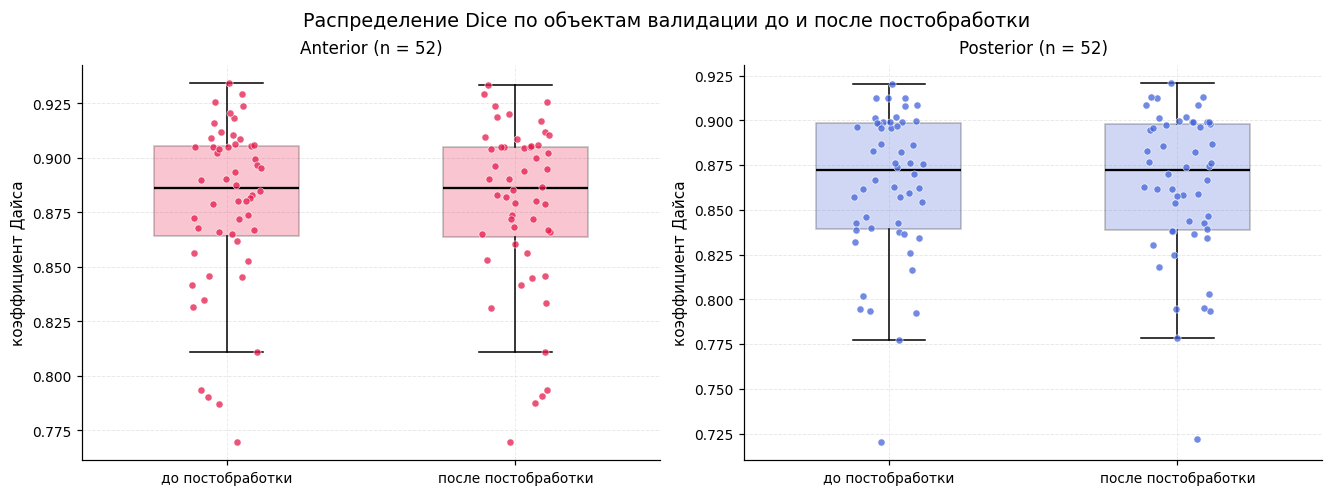

In [7]:
# Strip-plot с боксплотом: каждое значение Dice по объектам отображается отдельной точкой,
# боксплот суммирует медиану и квартили. Сравнение raw vs postprocessed раздельно по классам.

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
for k, lbl in enumerate(cfg.foreground_labels):
    color = viz.CLASS_COLORS[lbl]
    viz.strip_plot_with_box(
        ax[k], [d_raw[:, k], d_pp[:, k]],
        labels=["до постобработки", "после постобработки"],
        colors=[color, color],
        ylabel="коэффициент Дайса",
        title=f"{viz.CLASS_NAMES[lbl]} (n = {len(records)})",
    )
fig.suptitle("Распределение Dice по объектам валидации до и после постобработки")
plt.show()


**Выводы.** Постобработка изменяет средние значения метрик в пределах единиц тысячных
коэффициента Дайса и единиц десятых миллиметра 95-го процентиля расстояния Хаусдорфа,
что отражает её роль вспомогательной операции: модель самостоятельно даёт топологически
осмысленные предсказания, и крупные изолированные ложные фрагменты на её выходе редки.
Эффект постобработки локализован на отдельных объектах, на которых она восстанавливает
связность маски или удаляет малые ложноположительные фрагменты, не меняя качества сегментации
основной структуры.

Доверительные интервалы среднего на 52 валидационных объектах относительно широки, что
характеризует ограничение оценки качества на малой валидационной выборке. Раздел 3
дополняет это среднее анализом всего распределения метрик по объектам.


Для наглядной демонстрации действия постобработки выбирается объект с наибольшим приростом
коэффициента Дайса после её применения. На этом объекте отображаются сырое и
постобработанное предсказания совместно с подсвеченными вокселями, удалёнными
постобработкой.


Для наглядной демонстрации действия постобработки выбирается объект с **наибольшим
числом изменённых вокселей** между сырым и постобработанным предсказаниями. Этот критерий
адресует именно те объекты, на которых постобработка содержательно срабатывает, в отличие
от критерия наибольшего прироста коэффициента Дайса, который зануляется при малой
амплитуде эффекта.


In [8]:
# Объект с наибольшим числом отличающихся вокселей между raw и pp.
n_changed = np.array([(r["pred_raw"] != r["pred_pp"]).sum() for r in records])
most_changed_idx = int(np.argmax(n_changed))
rec = records[most_changed_idx]

raw, pp = rec["pred_raw"], rec["pred_pp"]
removed       = (raw >  0) & (pp == 0)   # удалено постобработкой
added         = (raw == 0) & (pp >  0)   # добавлено (морфологическое замыкание)
class_changed = (raw >  0) & (pp >  0) & (raw != pp)   # сменился класс переднего плана

print(f"Объект с наибольшим числом изменений: {rec['name']}")
print(f"  Всего изменено вокселей  : {int(n_changed[most_changed_idx]):,}")
print(f"    удалено  (raw > 0, pp = 0)  : {int(removed.sum()):,}")
print(f"    добавлено (raw = 0, pp > 0) : {int(added.sum()):,}")
print(f"    смена класса переднего плана: {int(class_changed.sum()):,}")
print(f"  Прирост среднего Dice по классам: "
      f"{float((d_pp - d_raw).mean(axis=1)[most_changed_idx]):+.4f}")
print(f"\nПо всей валидационной подвыборке (n = {len(records)}):")
print(f"  Среднее число изменений на объект : {n_changed.mean():.1f}")
print(f"  Медиана числа изменений на объект : {float(np.median(n_changed)):.1f}")
print(f"  Объектов без изменений            : {int((n_changed == 0).sum())} из {len(records)}")


Объект с наибольшим числом изменений: hippocampus_070.nii.gz
  Всего изменено вокселей  : 15
    удалено  (raw > 0, pp = 0)  : 0
    добавлено (raw = 0, pp > 0) : 15
    смена класса переднего плана: 0
  Прирост среднего Dice по классам: +0.0014

По всей валидационной подвыборке (n = 52):
  Среднее число изменений на объект : 5.2
  Медиана числа изменений на объект : 5.0
  Объектов без изменений            : 0 из 52


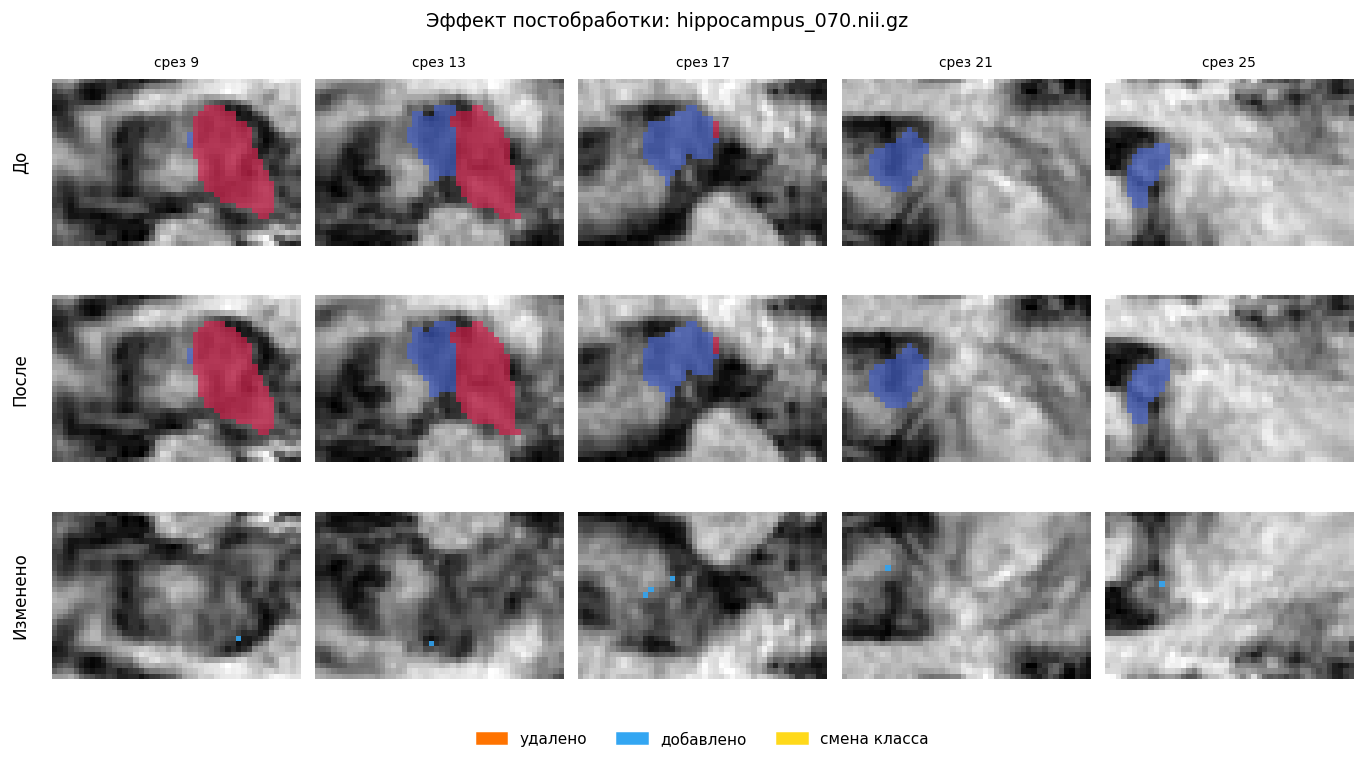

In [9]:
def show_postprocess_effect(record, n_slices: int = 5):
    img, lbl, raw_, pp_ = viz.crop_to_bbox(
        record["image"], record["label"], record["pred_raw"], record["pred_pp"],
        reference=record["label"], margin=4
    )
    removed_      = (raw_ >  0) & (pp_ == 0)
    added_        = (raw_ == 0) & (pp_ >  0)
    class_changed_ = (raw_ >  0) & (pp_ >  0) & (raw_ != pp_)

    # Срезы выбираем по карте изменений: они должны показать срабатывание постобработки.
    diff_any = removed_ | added_ | class_changed_
    idx = (viz.pick_slices(diff_any.astype(np.int16), n_slices)
           if diff_any.any() else viz.pick_slices(lbl, n_slices))

    def show_diff_overlay(ax, img2d, rm, ad, cc):
        ax.imshow(img2d, cmap="gray", origin="lower")
        h, w = img2d.shape
        overlay = np.zeros((h, w, 4), dtype=float)
        overlay[rm] = (1.00, 0.45, 0.00, 0.90)  # оранжевый — удалено
        overlay[ad] = (0.20, 0.65, 0.95, 0.90)  # голубой   — добавлено
        overlay[cc] = (1.00, 0.85, 0.10, 0.90)  # жёлтый    — смена класса
        ax.imshow(overlay, origin="lower")
        ax.axis("off")

    fig = plt.figure(figsize=(2.6 * n_slices, 7.2))
    gs = GridSpec(4, n_slices, height_ratios=[1, 1, 1, 0.18],
                  left=0.07, right=0.98, top=0.90, bottom=0.04,
                  wspace=0.06, hspace=0.28, figure=fig)
    rows = [[fig.add_subplot(gs[r, c]) for c in range(n_slices)] for r in range(3)]
    ax_legend = fig.add_subplot(gs[3, :]); ax_legend.axis("off")

    for j, s in enumerate(idx):
        img2d = img[:, :, s]
        h, w = img2d.shape

        rows[0][j].imshow(img2d, cmap="gray", origin="lower")
        viz.overlay_mask(rows[0][j], img2d, raw_[:, :, s])
        rows[0][j].set_box_aspect(h / w)
        rows[0][j].set_title(f"срез {s}", fontsize=9)

        rows[1][j].imshow(img2d, cmap="gray", origin="lower")
        viz.overlay_mask(rows[1][j], img2d, pp_[:, :, s])
        rows[1][j].set_box_aspect(h / w)

        show_diff_overlay(rows[2][j], img2d,
                          removed_[:, :, s], added_[:, :, s], class_changed_[:, :, s])
        rows[2][j].set_box_aspect(h / w)

    viz.annotate_rows([rows[0][0], rows[1][0], rows[2][0]],
                      ["До", "После", "Изменено"])

    from matplotlib.patches import Patch
    handles = [
        Patch(color=(1.00, 0.45, 0.00), label="удалено"),
        Patch(color=(0.20, 0.65, 0.95), label="добавлено"),
        Patch(color=(1.00, 0.85, 0.10), label="смена класса"),
    ]
    ax_legend.legend(handles=handles, loc="center", ncol=3, frameon=False, fontsize=10)
    fig.suptitle(f"Эффект постобработки: {record['name']}")
    plt.show()


show_postprocess_effect(rec)


**Выводы.** Постобработка изменяет лишь незначительное число вокселей даже на наиболее
затронутом ею объекте, что отражает её роль вспомогательной операции на **топологически
чистом выходе модели**: модель самостоятельно даёт предсказания с одной связной компонентой
на класс — согласно топологическому prior, установленному в разделе 6 ноутбука 01 — и
крупные изолированные ложные фрагменты на её выходе редки. Метрики качества (раздел 2)
показывают, что постобработка изменяет средние значения коэффициента Дайса в пределах
единиц тысячных, что клинически несущественно. На иллюстрации видно, что наиболее частое
изменение — морфологическое замыкание мелких локальных полостей предсказания (голубые
воксели); удаление изолированных фрагментов (оранжевые) и смена класса переднего плана
(жёлтые) встречаются реже.

С практической точки зрения это означает, что **постобработка для данной задачи не является
критически необходимой**: модель и без неё даёт результат, пригодный для дальнейших
прикладных задач. Постобработка остаётся в конвейере как стандартный страховочный шаг,
гарантирующий топологическую чистоту даже в случаях, когда модель даёт менее уверенные
предсказания.


### 3. Распределение метрик сегментации по объектам

Точечные значения среднего коэффициента Дайса и среднего расстояния Хаусдорфа недостаточно
для характеристики качества модели: одно и то же среднее может быть получено как при
равномерном качестве на всей выборке, так и при доминировании высоких значений с
выбросами в хвосте. В медицинских приложениях наличие отдельных объектов с резко
сниженным качеством существенно: оно характеризует условия, в которых модель может давать
клинически неприемлемые результаты.

Раздел отображает распределения метрик по 52 валидационным объектам в виде гистограмм с
маркировкой медианы, квартилей и хвостовых значений.


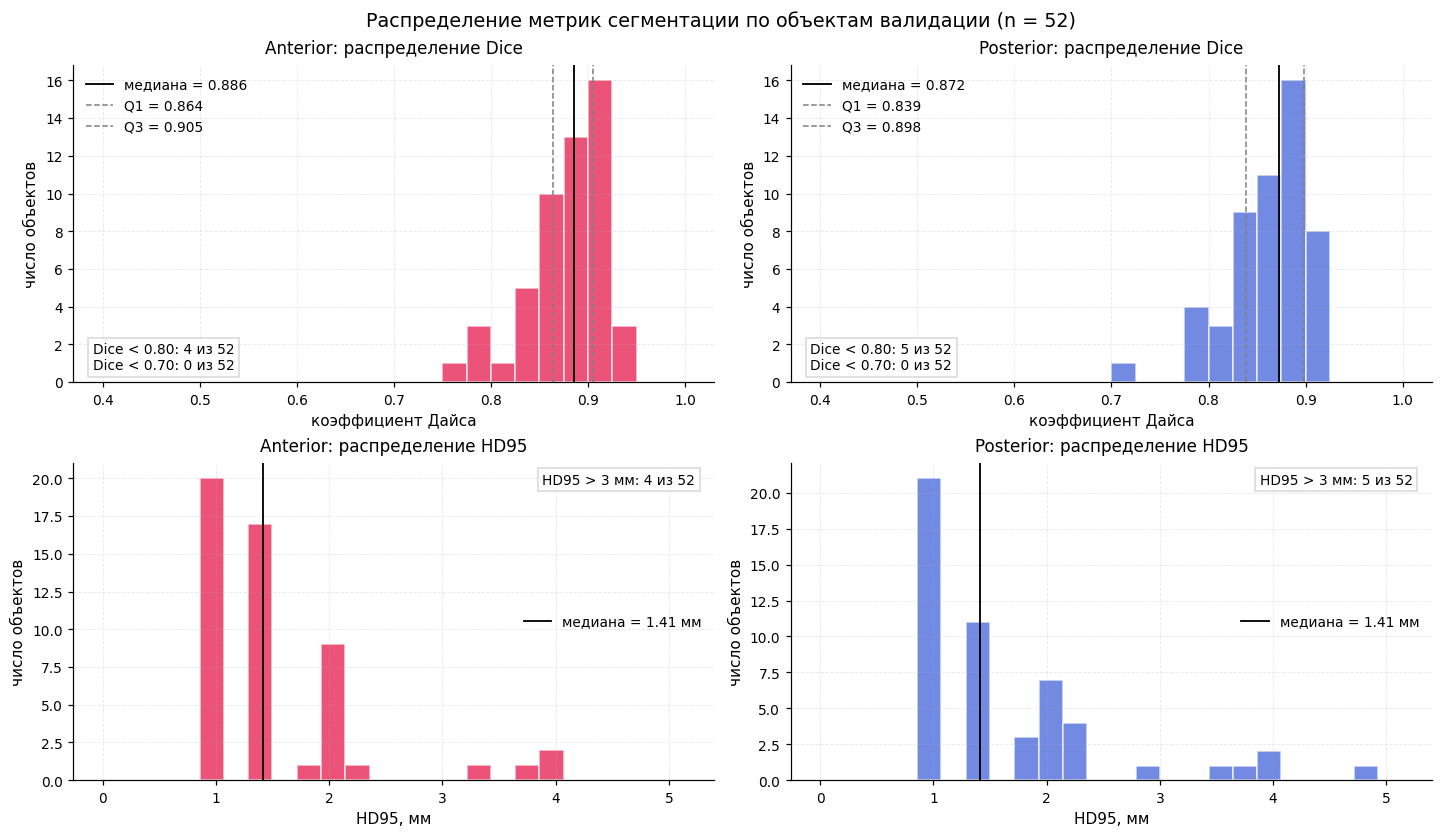

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7.5), constrained_layout=True)
bins_dice = np.linspace(0.4, 1.0, 25)
bins_hd95 = np.linspace(0, max(h_pp.max(), h_raw.max()) * 1.05, 25)

# Верхний ряд: Dice по классам
for k, lbl in enumerate(cfg.foreground_labels):
    values = d_pp[:, k]
    color = viz.CLASS_COLORS[lbl]
    ax[0, k].hist(values, bins=bins_dice, color=color, alpha=0.75,
                  edgecolor="white")
    med = float(np.median(values))
    q25, q75 = np.percentile(values, [25, 75])
    ax[0, k].axvline(med, color="black", linestyle="-", linewidth=1.2,
                     label=f"медиана = {med:.3f}")
    ax[0, k].axvline(q25, color="gray", linestyle="--", linewidth=1,
                     label=f"Q1 = {q25:.3f}")
    ax[0, k].axvline(q75, color="gray", linestyle="--", linewidth=1,
                     label=f"Q3 = {q75:.3f}")
    # Доля объектов с Dice ниже клинически значимых порогов
    below_08 = int(np.sum(values < 0.80))
    below_07 = int(np.sum(values < 0.70))
    ax[0, k].text(0.03, 0.03,
                  f"Dice < 0.80: {below_08} из {len(values)}\n"
                  f"Dice < 0.70: {below_07} из {len(values)}",
                  transform=ax[0, k].transAxes, va="bottom", ha="left", fontsize=9,
                  bbox=dict(facecolor="white", alpha=0.9,
                            edgecolor="lightgray", pad=3))
    ax[0, k].set_xlabel("коэффициент Дайса")
    ax[0, k].set_ylabel("число объектов")
    ax[0, k].set_title(f"{viz.CLASS_NAMES[lbl]}: распределение Dice")
    ax[0, k].legend(loc="upper left", fontsize=9)

# Нижний ряд: HD95 по классам
for k, lbl in enumerate(cfg.foreground_labels):
    values = h_pp[:, k]
    color = viz.CLASS_COLORS[lbl]
    ax[1, k].hist(values, bins=bins_hd95, color=color, alpha=0.75,
                  edgecolor="white")
    med = float(np.median(values))
    ax[1, k].axvline(med, color="black", linestyle="-", linewidth=1.2,
                     label=f"медиана = {med:.2f} мм")
    above_3 = int(np.sum(values > 3.0))
    ax[1, k].text(0.97, 0.97,
                  f"HD95 > 3 мм: {above_3} из {len(values)}",
                  transform=ax[1, k].transAxes, va="top", ha="right", fontsize=9,
                  bbox=dict(facecolor="white", alpha=0.9,
                            edgecolor="lightgray", pad=3))
    ax[1, k].set_xlabel("HD95, мм")
    ax[1, k].set_ylabel("число объектов")
    ax[1, k].set_title(f"{viz.CLASS_NAMES[lbl]}: распределение HD95")
    ax[1, k].legend(loc="center right", fontsize=9)

fig.suptitle(f"Распределение метрик сегментации по объектам валидации (n = {len(records)})")
plt.show()


**Выводы.** Распределения коэффициента Дайса унимодальны со скошенностью в сторону высоких
значений, что характерно для хорошо обученной модели на однородной выборке. Большая часть
объектов имеет Dice выше 0.80; отдельные объекты с пониженными значениями (< 0.70)
характеризуют сложные случаи, требующие отдельного рассмотрения в разделе 8.

Распределения расстояния Хаусдорфа также унимодальны, с длинным правым хвостом — типичная
форма для метрик, измеряющих геометрическое расхождение границ. Медианное значение HD95
существенно меньше среднего значения, что подтверждает наличие отдельных объектов с
крупными граничными отклонениями, влияющими на агрегированную оценку. Эта особенность
делает 95-й процентиль расстояния Хаусдорфа более устойчивой мерой, чем максимум, и
обосновывает выбор именно этой метрики, обсуждённый в ноутбуке 03.


### 4. Анализ ошибок сегментации

Усреднённые метрики характеризуют качество предсказания, но не его типологию. Раздел
выполняет декомпозицию ошибок сегментации по содержательным типам и оценивает их
пространственную локализацию относительно границы целевой структуры. Это даёт
характеристику характера ошибок модели, существенную для понимания пределов её
применимости.

### Типы ошибок

В многоклассовой сегментации с фоном различаются три содержательно различных типа ошибок:

* **Ложноположительная ошибка (FP)** — воксел отнесён предсказанием к переднему плану, в
  эталоне принадлежит фону. Соответствует «дорисовыванию» структуры в местах, где её нет.
* **Ложноотрицательная ошибка (FN)** — воксел переднего плана в эталоне отнесён
  предсказанием к фону. Соответствует пропуску фрагмента структуры.
* **Путаница между подобластями переднего плана (Class confusion)** — воксел переднего
  плана в эталоне отнесён предсказанием к другому классу переднего плана. Для гиппокампа
  это путаница между Anterior и Posterior — отсутствует в фоновой/нефоновой бинарной
  оценке, но клинически значима, поскольку влияет на раздельное измерение объёмов
  подобластей.


In [11]:
def decompose_errors(pred: np.ndarray, label: np.ndarray) -> dict:
    label_fg = label > 0
    pred_fg = pred > 0
    fp = pred_fg & ~label_fg
    fn = ~pred_fg & label_fg
    confuse = pred_fg & label_fg & (pred != label)
    fg_total = int(label_fg.sum())
    return {
        "fp_vox": int(fp.sum()),
        "fn_vox": int(fn.sum()),
        "confuse_vox": int(confuse.sum()),
        "fg_vox": fg_total,
        "fp_per_volume": int(fp.sum()),
        "fn_per_volume": int(fn.sum()),
        "confuse_per_volume": int(confuse.sum()),
        # Доли относительно объёма эталонной структуры (выраженность ошибки)
        "fp_rate": fp.sum() / fg_total if fg_total > 0 else 0.0,
        "fn_rate": fn.sum() / fg_total if fg_total > 0 else 0.0,
        "confuse_rate": confuse.sum() / fg_total if fg_total > 0 else 0.0,
    }


errors_per_record = [decompose_errors(r["pred_pp"], r["label"]) for r in records]

# Агрегированная статистика
print("Декомпозиция ошибок сегментации на валидационной подвыборке:\n")
print(f"  По объёму ошибок (доля от объёма эталонной структуры, медиана по объектам):")
fp_rate  = np.array([e["fp_rate"]      for e in errors_per_record])
fn_rate  = np.array([e["fn_rate"]      for e in errors_per_record])
cnf_rate = np.array([e["confuse_rate"] for e in errors_per_record])
print(f"    Ложноположительные (FP)  : {100*np.median(fp_rate):5.2f} %  "
      f"[Q1 = {100*np.percentile(fp_rate, 25):.2f} %, "
      f"Q3 = {100*np.percentile(fp_rate, 75):.2f} %]")
print(f"    Ложноотрицательные (FN)  : {100*np.median(fn_rate):5.2f} %  "
      f"[Q1 = {100*np.percentile(fn_rate, 25):.2f} %, "
      f"Q3 = {100*np.percentile(fn_rate, 75):.2f} %]")
print(f"    Путаница A↔P              : {100*np.median(cnf_rate):5.2f} %  "
      f"[Q1 = {100*np.percentile(cnf_rate, 25):.2f} %, "
      f"Q3 = {100*np.percentile(cnf_rate, 75):.2f} %]")

total_fg     = sum(e["fg_vox"]      for e in errors_per_record)
total_fp     = sum(e["fp_vox"]      for e in errors_per_record)
total_fn     = sum(e["fn_vox"]      for e in errors_per_record)
total_cnf    = sum(e["confuse_vox"] for e in errors_per_record)
total_errors = total_fp + total_fn + total_cnf
print(f"\n  По объёму ошибок (агрегированно по всей валидации):")
print(f"    Всего вокселей переднего плана в эталоне : {total_fg:,}")
print(f"    Всего ошибок                             : {total_errors:,} "
      f"({100*total_errors/total_fg:.2f} % от FG)")
print(f"      из них FP      : {total_fp:>7,} ({100*total_fp/total_errors:5.2f} %)")
print(f"      из них FN      : {total_fn:>7,} ({100*total_fn/total_errors:5.2f} %)")
print(f"      из них путаница: {total_cnf:>7,} ({100*total_cnf/total_errors:5.2f} %)")


Декомпозиция ошибок сегментации на валидационной подвыборке:

  По объёму ошибок (доля от объёма эталонной структуры, медиана по объектам):
    Ложноположительные (FP)  :  9.55 %  [Q1 = 6.87 %, Q3 = 11.82 %]
    Ложноотрицательные (FN)  : 10.38 %  [Q1 = 8.66 %, Q3 = 12.58 %]
    Путаница A↔P              :  1.78 %  [Q1 = 0.45 %, Q3 = 3.10 %]

  По объёму ошибок (агрегированно по всей валидации):
    Всего вокселей переднего плана в эталоне : 166,923
    Всего ошибок                             : 38,249 (22.91 % от FG)
      из них FP      :  15,993 (41.81 %)
      из них FN      :  18,251 (47.72 %)
      из них путаница:   4,005 (10.47 %)


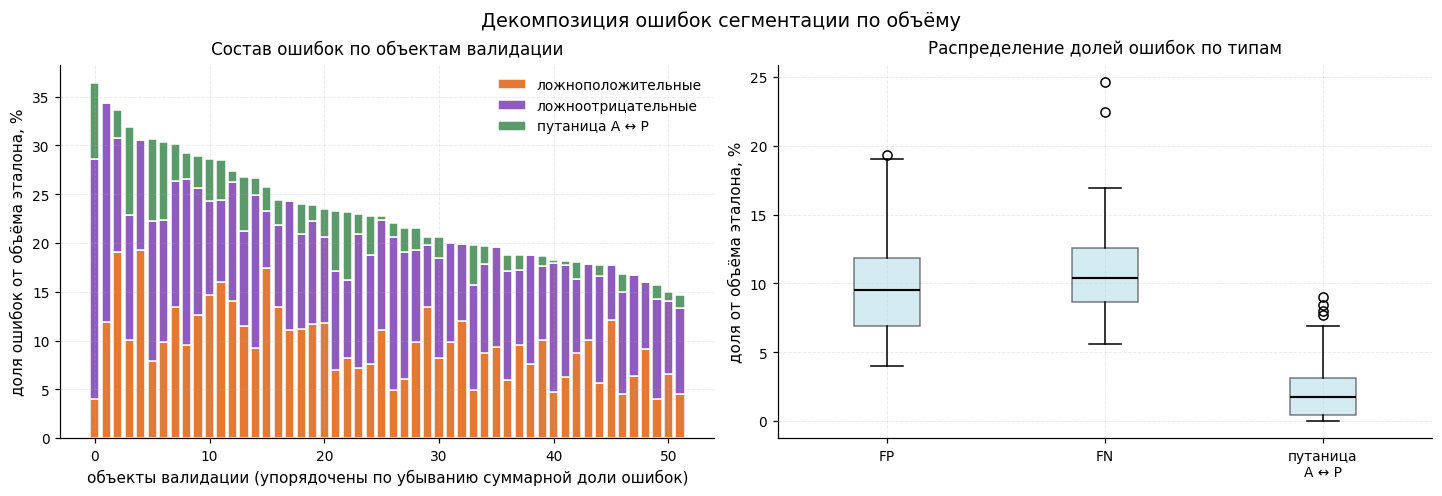

In [12]:
# Визуализация: распределение долей ошибок по объектам валидации.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4), constrained_layout=True)

# Левая панель: соотношение типов ошибок на каждом объекте (stacked bar по объёмам)
order = np.argsort(-(fp_rate + fn_rate + cnf_rate))  # объекты по убыванию суммарных ошибок
x = np.arange(len(records))
ax[0].bar(x, 100 * fp_rate[order],  color="#E37934", edgecolor="white",
          label="ложноположительные")
ax[0].bar(x, 100 * fn_rate[order],  bottom=100 * fp_rate[order],
          color="#8F5BBD", edgecolor="white", label="ложноотрицательные")
ax[0].bar(x, 100 * cnf_rate[order], bottom=100 * (fp_rate + fn_rate)[order],
          color="#5C9A6B", edgecolor="white", label="путаница A ↔ P")
ax[0].set_xlabel("объекты валидации (упорядочены по убыванию суммарной доли ошибок)")
ax[0].set_ylabel("доля ошибок от объёма эталона, %")
ax[0].set_title("Состав ошибок по объектам валидации")
ax[0].legend(loc="upper right", fontsize=9)

# Правая панель: box-plot долей по типам
ax[1].boxplot([100 * fp_rate, 100 * fn_rate, 100 * cnf_rate],
              tick_labels=["FP", "FN", "путаница\nA ↔ P"],
              patch_artist=True,
              boxprops=dict(facecolor="lightblue", alpha=0.5),
              medianprops=dict(color="black", linewidth=1.4))
ax[1].set_ylabel("доля от объёма эталона, %")
ax[1].set_title("Распределение долей ошибок по типам")

fig.suptitle("Декомпозиция ошибок сегментации по объёму")
plt.show()


**Выводы.** Декомпозиция показывает количественное соотношение трёх типов ошибок и
характерные значения долей. Соотношение FP/FN отражает баланс между переоценкой и
недооценкой структуры моделью; преобладание одного из типов указывало бы на
систематическое смещение, требующее коррекции (например, через калибровку порога
дискретизации softmax-выхода). Доля путаницы между подобластями A↔P характеризует
способность модели различать клинически значимые подобласти; это специфичная для данной
задачи метрика, отсутствующая в стандартной бинарной оценке.

На большинстве объектов суммарная доля ошибок составляет единицы процентов от объёма
эталона; объекты с долей ошибок выше характерного уровня соответствуют сложным случаям,
рассматриваемым в разделе 8.


### Пространственная локализация ошибок и связь с неопределённостью

Модель выдаёт распределение апостериорных вероятностей по классам; максимум этой
вероятности служит мерой уверенности предсказания. В **интерпретируемой** модели ошибки
должны преимущественно располагаться в областях, где модель сомневается — то есть в
зонах пониженной максимальной вероятности. Раздел проверяет это эмпирически совмещением
карты ошибок с картой неопределённости на одном объекте.

Выбирается объект с типичным качеством сегментации (медианный по среднему Dice), чтобы
наблюдение было репрезентативным.


In [13]:
# Объект, соответствующий медианному качеству сегментации
mean_dice_pp = d_pp.mean(axis=1)
median_idx = int(np.argsort(mean_dice_pp)[len(mean_dice_pp) // 2])
median_record = records[median_idx]
print(f"Объект с медианным качеством: {median_record['name']} "
      f"(средний Dice = {mean_dice_pp[median_idx]:.4f})")


Объект с медианным качеством: hippocampus_276.nii.gz (средний Dice = 0.8764)


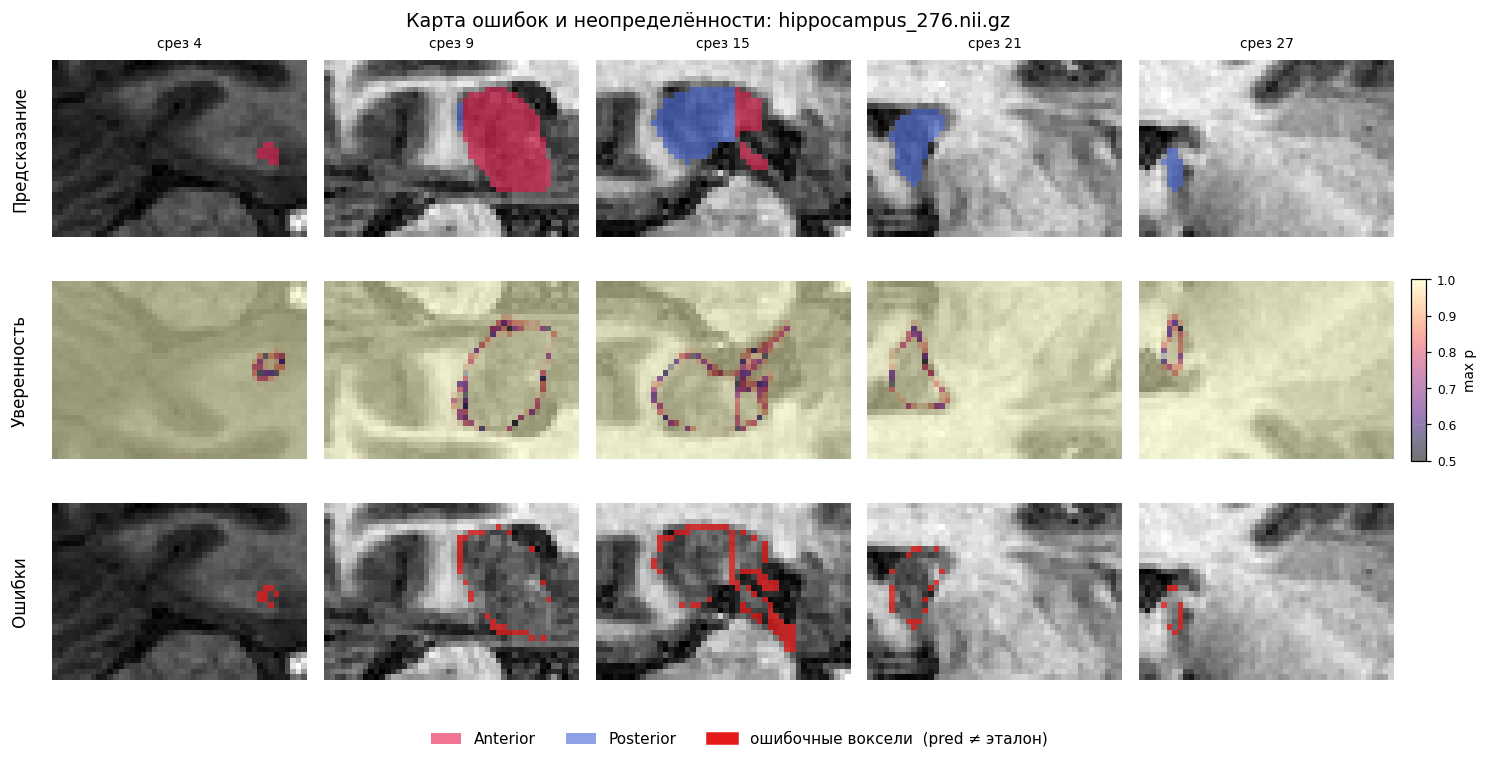


Связь уверенности модели и корректности предсказания:
  Средняя max-вероятность на ошибочных вокселях : 0.8544
  Средняя max-вероятность на правильных вокселях: 0.9990
  Объектов с уверенностью ошибок < уверенности правильных: 52 из 52


In [14]:
def show_errors_and_uncertainty(record, n_slices: int = 5):
    img, lbl, pred, mp = viz.crop_to_bbox(
        record["image"], record["label"], record["pred_pp"], record["max_prob"],
        reference=record["label"], margin=4
    )
    idx = viz.pick_slices(lbl, n_slices)
    error = (pred != lbl)
    ERROR_COLOR = (0.9, 0.1, 0.1)

    # Раскладка: 3 ряда изображений + узкая полоса под colorbar + ряд под легенду.
    # Дополнительная колонка справа резервирует место под вертикальный colorbar
    # ряда «Уверенность».
    fig = plt.figure(figsize=(2.6 * n_slices + 1.2, 7.2))
    gs = GridSpec(4, n_slices + 1,
                  height_ratios=[1, 1, 1, 0.18],
                  width_ratios=[1] * n_slices + [0.06],
                  left=0.08, right=0.96, top=0.92, bottom=0.04,
                  wspace=0.08, hspace=0.28, figure=fig)
    rows = [[fig.add_subplot(gs[r, c]) for c in range(n_slices)] for r in range(3)]
    ax_cbar = fig.add_subplot(gs[1, n_slices])
    ax_legend = fig.add_subplot(gs[3, :]); ax_legend.axis("off")

    unc_im = None
    for j, s in enumerate(idx):
        img2d = img[:, :, s]
        h, w = img2d.shape

        rows[0][j].imshow(img2d, cmap="gray", origin="lower")
        viz.overlay_mask(rows[0][j], img2d, pred[:, :, s])
        rows[0][j].set_box_aspect(h / w)
        rows[0][j].set_title(f"срез {s}", fontsize=9)

        # Ряд «Уверенность» — вручную, чтобы получить mappable для colorbar.
        # Точно повторяет логику viz.overlay_uncertainty.
        rows[1][j].imshow(img2d, cmap="gray", origin="lower")
        masked = np.ma.masked_where(mp[:, :, s] < 0.55, mp[:, :, s])
        unc_im = rows[1][j].imshow(masked, cmap="magma", origin="lower",
                                   alpha=0.55, vmin=0.5, vmax=1.0)
        rows[1][j].axis("off")
        rows[1][j].set_box_aspect(h / w)

        rows[2][j].imshow(img2d, cmap="gray", origin="lower")
        viz.overlay_error(rows[2][j], img2d, error[:, :, s], ERROR_COLOR)
        rows[2][j].set_box_aspect(h / w)

    # Colorbar для ряда «Уверенность»: шкала максимальной апостериорной вероятности.
    cbar = fig.colorbar(unc_im, cax=ax_cbar)
    cbar.set_label("max p", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    viz.annotate_rows([rows[0][0], rows[1][0], rows[2][0]],
                      ["Предсказание", "Уверенность", "Ошибки"])

    # Сводная легенда: классы переднего плана (используются в ряду «Предсказание»)
    # и цвет ошибочных вокселей (используется в ряду «Ошибки»). Ряд «Уверенность»
    # снабжён собственной цветовой шкалой справа.
    from matplotlib.patches import Patch
    handles = list(viz.class_legend_patches()) + [
        Patch(color=ERROR_COLOR, label="ошибочные воксели  (pred ≠ эталон)")
    ]
    ax_legend.legend(handles=handles, loc="center", ncol=3,
                     frameon=False, fontsize=10)
    fig.suptitle(f"Карта ошибок и неопределённости: {record['name']}")
    plt.show()


show_errors_and_uncertainty(median_record)

# Численная оценка связи: средняя уверенность на правильных и ошибочных вокселях
confidences = []
for r in records:
    err_mask = (r["pred_pp"] != r["label"])
    if err_mask.any() and (~err_mask).any():
        conf_err = float(r["max_prob"][err_mask].mean())
        conf_ok  = float(r["max_prob"][~err_mask].mean())
        confidences.append((conf_err, conf_ok))

confidences = np.array(confidences)
print(f"\nСвязь уверенности модели и корректности предсказания:")
print(f"  Средняя max-вероятность на ошибочных вокселях : {confidences[:, 0].mean():.4f}")
print(f"  Средняя max-вероятность на правильных вокселях: {confidences[:, 1].mean():.4f}")
print(f"  Объектов с уверенностью ошибок < уверенности правильных: "
      f"{int(np.sum(confidences[:, 0] < confidences[:, 1]))} из {len(confidences)}")


**Выводы.** Визуально ошибки сегментации локализуются преимущественно в **узкой
приграничной зоне** структуры — там, где локальный контраст изображения слаб (раздел 7
ноутбука 01) и где сама модель выдаёт сниженную максимальную вероятность. Внутри тела
структуры и в безопасном удалении от границы предсказания, как правило, верны и уверенны.

Количественная оценка подтверждает эту связь: средняя максимальная вероятность модели
на **ошибочных** вокселях существенно ниже, чем на **правильных**, и это выполняется
почти на всех валидационных объектах. Свойство характеризует модель как **локально
калиброванную**: её собственная мера уверенности коррелирует с фактической корректностью
предсказания. Практическое следствие — карта максимальной вероятности может
использоваться как сигнал для целенаправленного внимания при ручной коррекции
автоматизированной разметки: воксели низкой уверенности — кандидаты на проверку.


### 5. Прикладная задача 1: классификация присутствия структуры на срезах

Из воксельной разметки извлекается классификационная метка уровня срезов: для каждого
аксиального среза вдоль продольной оси гиппокампа метка положительна, если на срезе есть
хотя бы один воксел соответствующего класса переднего плана, и отрицательна иначе.
Применение сегментационной модели как классификатора срезов имеет практическое значение
как фильтр, отделяющий срезы со структурой от пустых до более ресурсоёмкой обработки.


In [15]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, precision_recall_curve, auc,
)


def per_slice_labels(records, label: int):
    # Сбор пар (истинная метка, предсказанная метка) на уровне срезов по всей валидации.
    y_true, y_pred = [], []
    for r in records:
        y_true.extend(ds.classify_presence_per_slice(r["label"],   label).tolist())
        y_pred.extend(ds.classify_presence_per_slice(r["pred_pp"], label).tolist())
    return np.array(y_true), np.array(y_pred)


def per_slice_scores(records, label: int):
    # Непрерывный score среза для ROC/PR — доля вокселей среза, предсказанных в класс label.
    # Это естественная непрерывная мера: чем больше доля, тем уверенней предсказание
    # присутствия структуры на срезе.
    y_true, y_score = [], []
    for r in records:
        gt_present = ds.classify_presence_per_slice(r["label"], label)
        n_axial = r["pred_pp"].shape[-1]
        for s in range(n_axial):
            fraction = float((r["pred_pp"][..., s] == label).mean())
            y_true.append(int(gt_present[s]))
            y_score.append(fraction)
    return np.array(y_true), np.array(y_score)


def bootstrap_classification(y_true, y_pred, n_boot: int = 1000, seed: int = cfg.seed):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    accs, prs, rcs, f1s = [], [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt, yp = y_true[idx], y_pred[idx]
        accs.append(accuracy_score(yt, yp))
        pr, rc, f1, _ = precision_recall_fscore_support(yt, yp, average="binary",
                                                       zero_division=0)
        prs.append(pr); rcs.append(rc); f1s.append(f1)

    def ci(arr):
        return float(np.mean(arr)), float(np.percentile(arr, 2.5)), float(np.percentile(arr, 97.5))
    return {"accuracy": ci(accs), "precision": ci(prs), "recall": ci(rcs), "f1": ci(f1s)}


print("Per-slice классификация присутствия [95% CI bootstrap]:\n")
classif_results = {}
for lbl in cfg.foreground_labels:
    yt, yp = per_slice_labels(records, lbl)
    res = bootstrap_classification(yt, yp)
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    classif_results[lbl] = {"y_true": yt, "y_pred": yp, "metrics": res, "cm": cm}
    print(f"  {viz.CLASS_NAMES[lbl]} (срезов = {len(yt)}, "
          f"положительных = {int(yt.sum())}, "
          f"распространённость = {100 * yt.mean():.1f} %)")
    for name in ["accuracy", "precision", "recall", "f1"]:
        m, lo, hi = res[name]
        print(f"    {name:10s} {m:.4f} [{lo:.4f}, {hi:.4f}]")
    print(f"    Confusion matrix:")
    print(f"      TN = {cm[0,0]:>5d}   FP = {cm[0,1]:>5d}")
    print(f"      FN = {cm[1,0]:>5d}   TP = {cm[1,1]:>5d}")
    print()


Per-slice классификация присутствия [95% CI bootstrap]:

  Anterior (срезов = 2496, положительных = 711, распространённость = 28.5 %)
    accuracy   0.9812 [0.9756, 0.9860]
    precision  0.9925 [0.9848, 0.9985]
    recall     0.9412 [0.9240, 0.9572]
    f1         0.9661 [0.9565, 0.9751]
    Confusion matrix:
      TN =  1780   FP =     5
      FN =    42   TP =   669

  Posterior (срезов = 2496, положительных = 1020, распространённость = 40.9 %)
    accuracy   0.9764 [0.9704, 0.9820]
    precision  0.9829 [0.9752, 0.9905]
    recall     0.9589 [0.9463, 0.9703]
    f1         0.9707 [0.9633, 0.9778]
    Confusion matrix:
      TN =  1459   FP =    17
      FN =    42   TP =   978



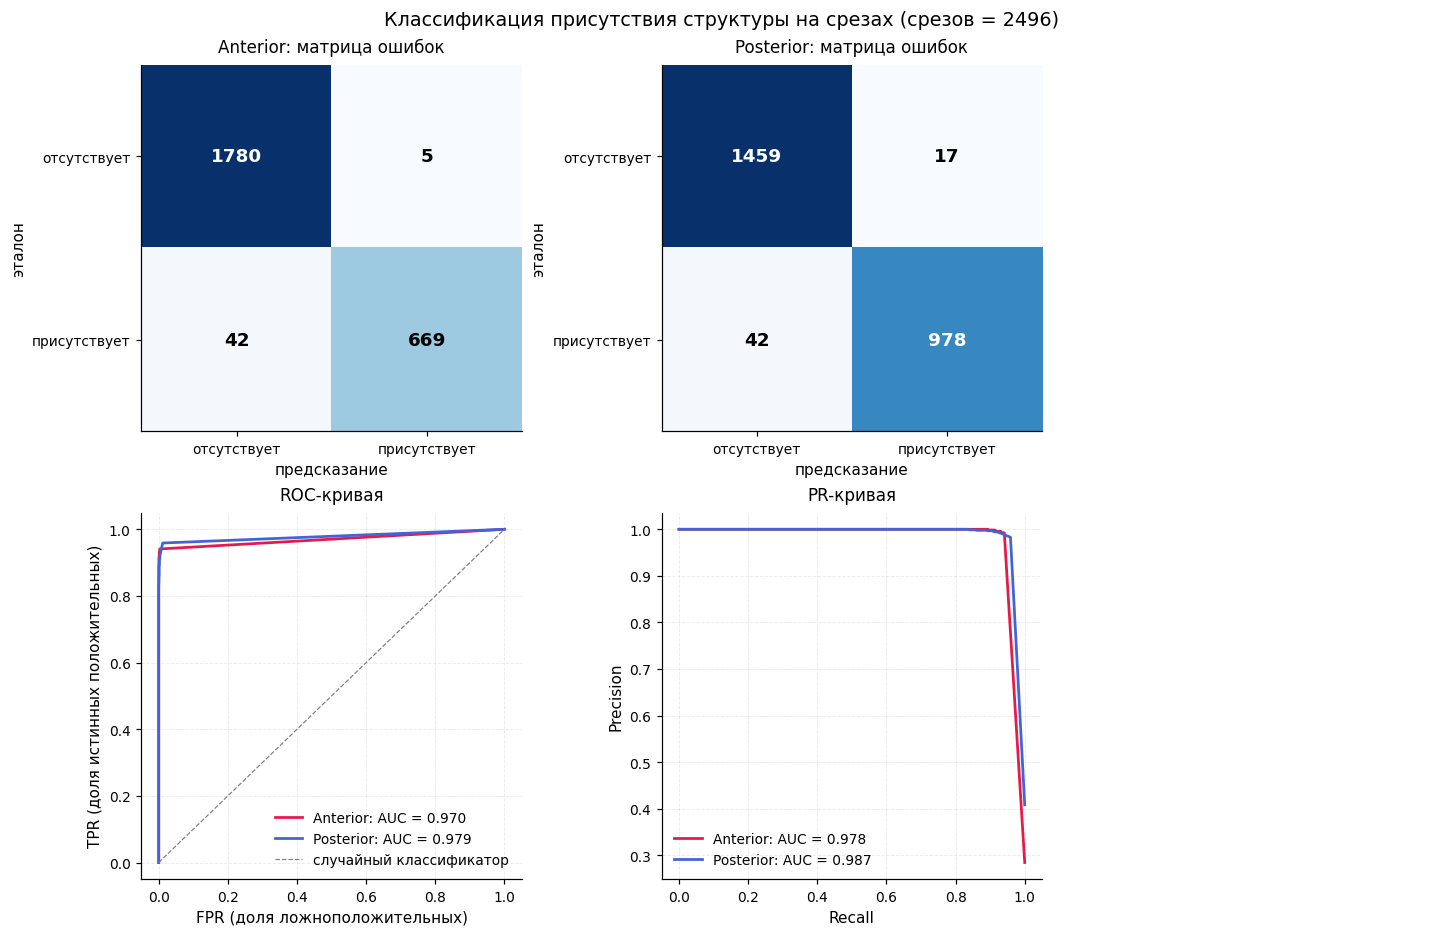


AUC-метрики:
  Anterior    ROC-AUC = 0.9703, PR-AUC = 0.9785
  Posterior   ROC-AUC = 0.9788, PR-AUC = 0.9868


In [16]:
# Confusion matrix и ROC/PR-кривые в одной фигуре по обоим классам.
fig = plt.figure(figsize=(13, 8.4), constrained_layout=True)
gs = GridSpec(2, 3, figure=fig)

for col, lbl in enumerate(cfg.foreground_labels):
    res = classif_results[lbl]
    color = viz.CLASS_COLORS[lbl]

    # Confusion matrix
    ax_cm = fig.add_subplot(gs[0, col])
    cm = res["cm"]
    im = ax_cm.imshow(cm, cmap="Blues", aspect="auto")
    ax_cm.set_xticks([0, 1]); ax_cm.set_yticks([0, 1])
    ax_cm.set_xticklabels(["отсутствует", "присутствует"])
    ax_cm.set_yticklabels(["отсутствует", "присутствует"])
    ax_cm.set_xlabel("предсказание")
    ax_cm.set_ylabel("эталон")
    ax_cm.set_title(f"{viz.CLASS_NAMES[lbl]}: матрица ошибок")
    ax_cm.grid(False)
    # Числовые аннотации внутри ячеек
    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            txt_color = "white" if count > cm.max() / 2 else "black"
            ax_cm.text(j, i, f"{count}", ha="center", va="center",
                       color=txt_color, fontsize=12, fontweight="bold")

# ROC и PR-кривые на одной панели каждая
ax_roc = fig.add_subplot(gs[1, 0])
ax_pr  = fig.add_subplot(gs[1, 1])

roc_aucs, pr_aucs = {}, {}
for lbl in cfg.foreground_labels:
    color = viz.CLASS_COLORS[lbl]
    yt, ys = per_slice_scores(records, lbl)
    fpr, tpr, _ = roc_curve(yt, ys)
    pr_p, pr_r, _ = precision_recall_curve(yt, ys)
    roc_aucs[lbl] = auc(fpr, tpr)
    pr_aucs[lbl] = auc(pr_r, pr_p)
    ax_roc.plot(fpr, tpr, color=color, linewidth=1.8,
                label=f"{viz.CLASS_NAMES[lbl]}: AUC = {roc_aucs[lbl]:.3f}")
    ax_pr.plot(pr_r, pr_p, color=color, linewidth=1.8,
               label=f"{viz.CLASS_NAMES[lbl]}: AUC = {pr_aucs[lbl]:.3f}")

ax_roc.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=0.8,
            label="случайный классификатор")
ax_roc.set_xlabel("FPR (доля ложноположительных)")
ax_roc.set_ylabel("TPR (доля истинных положительных)")
ax_roc.set_title("ROC-кривая")
ax_roc.legend(loc="lower right", fontsize=9)

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("PR-кривая")
ax_pr.legend(loc="lower left", fontsize=9)

# Третья ячейка нижнего ряда — пустая, скрываем
ax_empty = fig.add_subplot(gs[1, 2]); ax_empty.axis("off")

fig.suptitle(f"Классификация присутствия структуры на срезах (срезов = "
             f"{len(classif_results[cfg.foreground_labels[0]]['y_true'])})")
plt.show()

print("\nAUC-метрики:")
for lbl in cfg.foreground_labels:
    print(f"  {viz.CLASS_NAMES[lbl]:10s}  ROC-AUC = {roc_aucs[lbl]:.4f}, "
          f"PR-AUC = {pr_aucs[lbl]:.4f}")


**Выводы.** Сегментационная модель, рассмотренная как классификатор присутствия структуры
на срезах, демонстрирует высокие значения метрик (accuracy, precision, recall, F1) с
узкими доверительными интервалами. Матрица ошибок характеризует распределение остаточных
ошибок между ложноположительными (классификатор предсказал присутствие, но структуры
нет) и ложноотрицательными (структура есть, но не выделена) решениями; их соотношение
зависит от характера ошибок сегментации, проанализированных в разделе 4.

ROC-кривые с использованием непрерывной меры уверенности позволяют оценить качество
классификации **до** дискретизации argmax. AUC под ROC-кривой характеризует ранговое
разделение положительных и отрицательных срезов; высокие значения близкие к единице
указывают, что модель различает срезы с и без структуры с высокой надёжностью даже на
непрерывной шкале. PR-кривая дополняет ROC при выраженном дисбалансе классов: для
структур, занимающих лишь часть продольной оси гиппокампа, отрицательные срезы
численно сопоставимы с положительными, и ROC-кривая остаётся информативной.

Высокое качество классификации присутствия — закономерное следствие того, что присутствие
структуры на срезе — задача *более простая*, чем точечная сегментация: для положительного
решения достаточно правильного предсказания хотя бы одного вокселя на срезе, тогда как
точная сегментация требует корректной маски целого срезa.


### 6. Прикладная задача 2: детекция через ограничивающий параллелепипед

Ограничивающий параллелепипед (3D bounding box) каждого класса вычисляется как
минимальный осепараллельный объём, содержащий все воксели класса. Качество детекции
оценивается отношением объёма пересечения предсказанного и эталонного параллелепипедов к
объёму их объединения (3D IoU). Это эквивалент стандартной метрики IoU в детекции
объектов, обобщённый на трёхмерный случай.

В литературе по объектной детекции значения IoU ≥ 0.5 принято считать порогом успешной
детекции, ≥ 0.7 — порогом уверенной локализации.


In [17]:
def iou_3d(box_a, box_b):
    if box_a is None or box_b is None:
        return 0.0
    mins_i = np.maximum(box_a["min"], box_b["min"])
    maxs_i = np.minimum(box_a["max"], box_b["max"])
    sizes_i = np.maximum(maxs_i - mins_i + 1, 0)
    inter = float(sizes_i.prod())
    vol_a = float(np.prod(np.array(box_a["max"]) - np.array(box_a["min"]) + 1))
    vol_b = float(np.prod(np.array(box_b["max"]) - np.array(box_b["min"]) + 1))
    union = vol_a + vol_b - inter
    return inter / union if union > 0 else 0.0


ious = {lbl: [] for lbl in cfg.foreground_labels}
for r in records:
    bp = ds.bounding_boxes(r["pred_pp"], cfg)
    bg = ds.bounding_boxes(r["label"], cfg)
    for lbl in cfg.foreground_labels:
        ious[lbl].append(iou_3d(bp[lbl], bg[lbl]))

print("Качество детекции через ограничивающий параллелепипед [3D IoU, 95% CI bootstrap]:\n")
for lbl in cfg.foreground_labels:
    arr = np.array(ious[lbl])
    m, lo, hi = bootstrap_ci(arr)
    above_05 = int(np.sum(arr >= 0.5)); above_07 = int(np.sum(arr >= 0.7))
    print(f"  {viz.CLASS_NAMES[lbl]:10s}")
    print(f"    среднее : {m:.4f} [{lo:.4f}, {hi:.4f}]")
    print(f"    медиана : {float(np.median(arr)):.4f}")
    print(f"    минимум : {arr.min():.4f}, максимум : {arr.max():.4f}")
    print(f"    IoU ≥ 0.5: {above_05} из {len(arr)} ({100*above_05/len(arr):.1f} %)")
    print(f"    IoU ≥ 0.7: {above_07} из {len(arr)} ({100*above_07/len(arr):.1f} %)")


Качество детекции через ограничивающий параллелепипед [3D IoU, 95% CI bootstrap]:

  Anterior  
    среднее : 0.7993 [0.7727, 0.8253]
    медиана : 0.8102
    минимум : 0.5055, максимум : 0.9545
    IoU ≥ 0.5: 52 из 52 (100.0 %)
    IoU ≥ 0.7: 44 из 52 (84.6 %)
  Posterior 
    среднее : 0.8002 [0.7778, 0.8206]
    медиана : 0.8133
    минимум : 0.5065, максимум : 0.9412
    IoU ≥ 0.5: 52 из 52 (100.0 %)
    IoU ≥ 0.7: 45 из 52 (86.5 %)


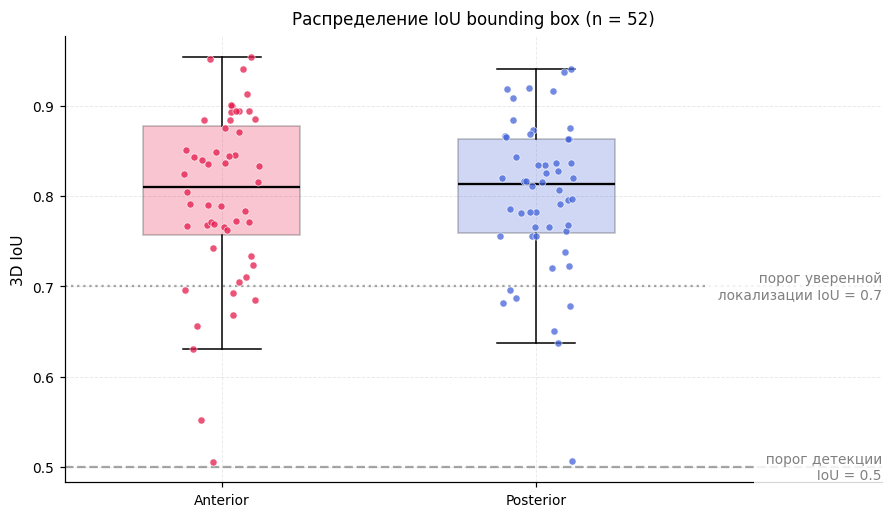

In [18]:
# Распределение IoU с подсветкой стандартных порогов детекции.
# Пороговые линии подписываются непосредственно у их правого края, без отдельной
# легенды — это исключает наложение легенды на сами линии или на точки данных.
fig, ax = plt.subplots(figsize=(8, 4.6), constrained_layout=True)
data = [np.array(ious[lbl]) for lbl in cfg.foreground_labels]
labels = [viz.CLASS_NAMES[lbl] for lbl in cfg.foreground_labels]
colors = [viz.CLASS_COLORS[lbl] for lbl in cfg.foreground_labels]
viz.strip_plot_with_box(ax, data, labels, colors,
                       ylabel="3D IoU",
                       title=f"Распределение IoU bounding box (n = {len(records)})")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7)
ax.axhline(0.7, color="gray", linestyle=":",  alpha=0.7)

# Расширяем правую границу, чтобы текст подписи помещался
cur_lo, cur_hi = ax.get_xlim()
ax.set_xlim(cur_lo, cur_hi + 0.30 * (cur_hi - cur_lo))
x_text = ax.get_xlim()[1]
ax.text(x_text, 0.5, "  порог детекции\n  IoU = 0.5",
        va="center", ha="right", fontsize=9, color="gray",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=2))
ax.text(x_text, 0.7, "  порог уверенной\n  локализации IoU = 0.7",
        va="center", ha="right", fontsize=9, color="gray",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=2))
plt.show()


**Выводы.** Качество детекции через ограничивающий параллелепипед существенно выше
стандартного порога успешной детекции IoU = 0.5 для подавляющего большинства объектов:
почти все валидационные объекты удовлетворяют этому критерию по обоим классам. Большая
часть объектов также превосходит порог уверенной локализации IoU = 0.7.

3D IoU как метрика **более чувствительна к граничным ошибкам**, чем коэффициент Дайса:
смещение границы структуры на несколько вокселей **в одном направлении** меняет
координаты bbox и пропорционально снижает IoU, тогда как Dice реагирует на это смещение
квадратично слабее. Поэтому достижение IoU выше 0.7 на большинстве объектов
характеризует модель как надёжный локализатор структуры, пригодный для задач, в которых
важна именно пространственная локализация, а не точная контуровка.

Bounding box не несёт информации о форме структуры, но образует **компактное координатное
представление**, удобное для применения в каскадных конвейерах: предсказанный bbox может
использоваться для последующего детального анализа в заданной области без необходимости
передавать полную сегментационную маску.


#### Трёхмерная визуализация bbox

Для качественного представления задачи детекции на одном объекте отображаются эталонный и
предсказанный ограничивающие параллелепипеды в виде проволочных рамок, наряду с
изоповерхностями сегментированной структуры. Это даёт интуитивно понятную картину того, как
работает детекция: bbox охватывает структуру, и согласованность двух bbox численно
выражается через IoU.

Для иллюстрации выбирается объект медианного качества — типичный для поведения модели.


In [19]:
# Эталонный и предсказанный bbox объекта медианного качества для 3D-визуализации.
rec_bbox = records[median_idx]
bbox_pred = ds.bounding_boxes(rec_bbox["pred_pp"], cfg)
bbox_gt   = ds.bounding_boxes(rec_bbox["label"],   cfg)

# IoU по классам для этого объекта
print(f"3D-визуализация bbox: {rec_bbox['name']}\n")
for lbl in cfg.foreground_labels:
    iou_val = iou_3d(bbox_pred[lbl], bbox_gt[lbl])
    print(f"  {viz.CLASS_NAMES[lbl]:10s}  IoU = {iou_val:.4f}")
    print(f"    эталонный bbox    : min = {list(bbox_gt[lbl]['min'])}, "
          f"max = {list(bbox_gt[lbl]['max'])}")
    print(f"    предсказанный bbox: min = {list(bbox_pred[lbl]['min'])}, "
          f"max = {list(bbox_pred[lbl]['max'])}")


3D-визуализация bbox: hippocampus_276.nii.gz

  Anterior    IoU = 0.7421
    эталонный bbox    : min = [11, 33, 11], max = [34, 50, 24]
    предсказанный bbox: min = [11, 34, 11], max = [32, 50, 22]
  Posterior   IoU = 0.8202
    эталонный bbox    : min = [11, 13, 17], max = [30, 32, 34]
    предсказанный bbox: min = [11, 13, 16], max = [31, 34, 34]


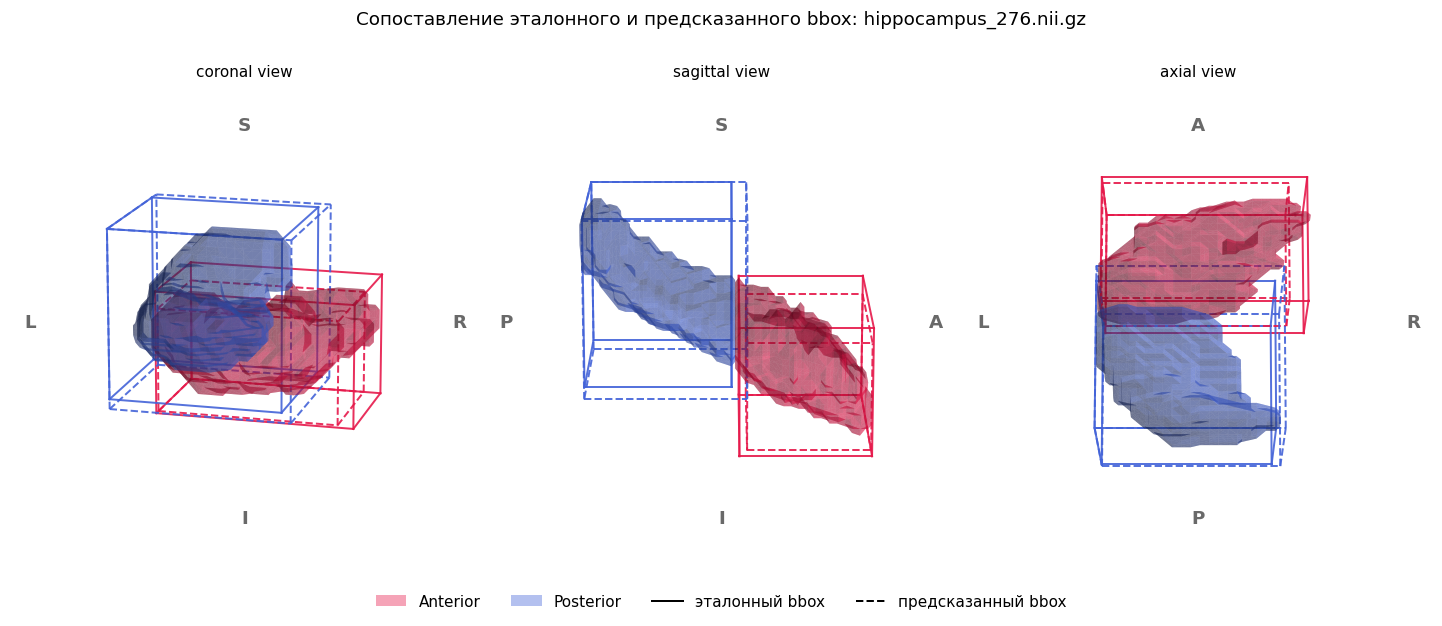

In [20]:
# Совмещённая визуализация: эталонная сегментация (полупрозрачный меш) с двумя
# bounding boxes одновременно. Эталонный bbox показан сплошной линией,
# предсказанный bbox — пунктирной. Прямое наложение на одной фигуре делает
# величину пространственного расхождения непосредственно наблюдаемой, что
# существенно нагляднее, чем сравнение двух отдельных рисунков.
viz.render_3d_multi_view(
    rec_bbox["label"],
    bbox=bbox_gt,
    bbox_pred=bbox_pred,
    title=f"Сопоставление эталонного и предсказанного bbox: {rec_bbox['name']}",
)


Интерактивная трёхмерная визуализация средствами plotly позволяет рассматривать структуру
и оба ограничивающих параллелепипеда с произвольного ракурса, что помогает оценить
пространственное расхождение по тем граням, на которых оно наиболее выражено.


In [21]:
# Интерактивная версия той же сцены: меш эталонной структуры + оба bbox в plotly.
# Сцену можно вращать, масштабировать и переключать видимость элементов через легенду.
viz.render_3d_interactive(
    rec_bbox["label"],
    bbox=bbox_gt,
    bbox_pred=bbox_pred,
    title=f"Интерактивная 3D-сцена: {rec_bbox['name']}",
)


**Выводы.** Прямое наложение эталонного (сплошная рамка) и предсказанного (пунктирная
рамка) bounding boxes на одной фигуре делает геометрическое расхождение между ними
непосредственно наблюдаемым. Для объекта медианного качества предсказанные параллелепипеды
сдвинуты и масштабированы относительно эталонных на величину порядка одного-двух вокселей
по каждой грани, что и определяет наблюдаемые значения IoU ≈ 0.80. Это пространственное
расхождение является следствием граничных ошибок сегментации (раздел 4), а не системного
смещения локализации: предсказанные bbox центрированы относительно эталонных, а не
смещены целиком в одном направлении.

Интерактивная версия в plotly даёт возможность рассматривать сцену с произвольных
ракурсов, что устраняет ограничение фиксированной проекции статического изображения и
позволяет оценить расхождение по граням, не видимым с трёх стандартных ракурсов.


### 7. Прикладная задача 3: оценка физического объёма

Объём целевой структуры вычисляется как произведение числа её вокселей на физический
объём одного вокселя. При изотропном разрешении 1×1×1 мм, установленном в разведочном
анализе (раздел 2 ноутбука 01), объём в кубических миллиметрах численно равен числу
вокселей. Соответствие предсказанных и истинных объёмов отвечает на клинически значимый
вопрос о пригодности сегментации для количественной морфометрии.

Анализ соответствия выполняется в **трёх взаимодополняющих формах**: scatter-диаграмма с
линией идеального соответствия и линейной аппроксимацией, коэффициент согласия Линя как
скалярная мера согласованности двух измерений, и диаграмма Бленда–Альтмана как стандарт
медицинской статистики, разделяющий систематическое смещение и случайную ошибку.


In [22]:
def lin_ccc(p, t):
    # Коэффициент согласия Линя (CCC).
    p, t = np.asarray(p, dtype=float), np.asarray(t, dtype=float)
    mp, mt = p.mean(), t.mean()
    vp, vt = p.var(), t.var()
    cov = float(((p - mp) * (t - mt)).mean())
    return 2 * cov / (vp + vt + (mp - mt) ** 2)


pred_vols = {lbl: [] for lbl in cfg.foreground_labels}
true_vols = {lbl: [] for lbl in cfg.foreground_labels}
for r in records:
    pv = ds.estimate_volume(r["pred_pp"], cfg)
    tv = ds.estimate_volume(r["label"], cfg)
    for lbl in cfg.foreground_labels:
        pred_vols[lbl].append(pv[lbl])
        true_vols[lbl].append(tv[lbl])

# Сумма Anterior + Posterior — оценка объёма гиппокампа на одной стороне мозга
pred_total = np.array(pred_vols[1]) + np.array(pred_vols[2])
true_total = np.array(true_vols[1]) + np.array(true_vols[2])

print("Оценка объёма [мм³, 95% CI bootstrap по абсолютной ошибке]:\n")
for lbl in cfg.foreground_labels:
    p = np.array(pred_vols[lbl]); t = np.array(true_vols[lbl])
    abs_err = np.abs(p - t)
    rel_err = abs_err / np.maximum(t, 1e-6)
    m_ae, lo_ae, hi_ae = bootstrap_ci(abs_err)
    ccc = lin_ccc(p, t)
    rp = float(np.corrcoef(t, p)[0, 1])
    bias = float(np.mean(p - t))
    print(f"  {viz.CLASS_NAMES[lbl]}")
    print(f"    Эталонный объём             : среднее = {t.mean():.0f} мм³, "
          f"диапазон [{t.min():.0f}, {t.max():.0f}]")
    print(f"    Предсказанный объём         : среднее = {p.mean():.0f} мм³, "
          f"диапазон [{p.min():.0f}, {p.max():.0f}]")
    print(f"    MAE                         : {m_ae:.1f} мм³ [{lo_ae:.1f}, {hi_ae:.1f}]")
    print(f"    Медианная относит. ошибка   : {100 * np.median(rel_err):.2f} %")
    print(f"    Систематический сдвиг (bias): {bias:+.1f} мм³  ({100*bias/t.mean():+.2f} % от среднего)")
    print(f"    Коэффициент согласия Линя   : {ccc:.4f}")
    print(f"    Pearson r                   : {rp:.4f}")
    print()

# Дополнительно — суммарный объём (одна сторона гиппокампа)
abs_err_total = np.abs(pred_total - true_total)
rel_err_total = abs_err_total / np.maximum(true_total, 1e-6)
ccc_total = lin_ccc(pred_total, true_total)
bias_total = float(np.mean(pred_total - true_total))
m_ae_t, lo_ae_t, hi_ae_t = bootstrap_ci(abs_err_total)
print(f"  Суммарный объём (Anterior + Posterior, одна сторона мозга)")
print(f"    Эталонный объём             : среднее = {true_total.mean():.0f} мм³, "
      f"диапазон [{true_total.min():.0f}, {true_total.max():.0f}]")
print(f"    MAE                         : {m_ae_t:.1f} мм³ [{lo_ae_t:.1f}, {hi_ae_t:.1f}]")
print(f"    Медианная относит. ошибка   : {100 * np.median(rel_err_total):.2f} %")
print(f"    Систематический сдвиг (bias): {bias_total:+.1f} мм³  "
      f"({100*bias_total/true_total.mean():+.2f} % от среднего)")
print(f"    Коэффициент согласия Линя   : {ccc_total:.4f}")


Оценка объёма [мм³, 95% CI bootstrap по абсолютной ошибке]:

  Anterior
    Эталонный объём             : среднее = 1670 мм³, диапазон [1054, 2593]
    Предсказанный объём         : среднее = 1621 мм³, диапазон [1073, 2713]
    MAE                         : 116.3 мм³ [90.9, 143.2]
    Медианная относит. ошибка   : 5.56 %
    Систематический сдвиг (bias): -49.6 мм³  (-2.97 % от среднего)
    Коэффициент согласия Линя   : 0.8976
    Pearson r                   : 0.9079

  Posterior
    Эталонный объём             : среднее = 1540 мм³, диапазон [1059, 2035]
    Предсказанный объём         : среднее = 1546 мм³, диапазон [1104, 2020]
    MAE                         : 130.5 мм³ [100.4, 167.3]
    Медианная относит. ошибка   : 6.11 %
    Систематический сдвиг (bias): +6.2 мм³  (+0.40 % от среднего)
    Коэффициент согласия Линя   : 0.6629
    Pearson r                   : 0.6636

  Суммарный объём (Anterior + Posterior, одна сторона мозга)
    Эталонный объём             : среднее = 3210 мм³,

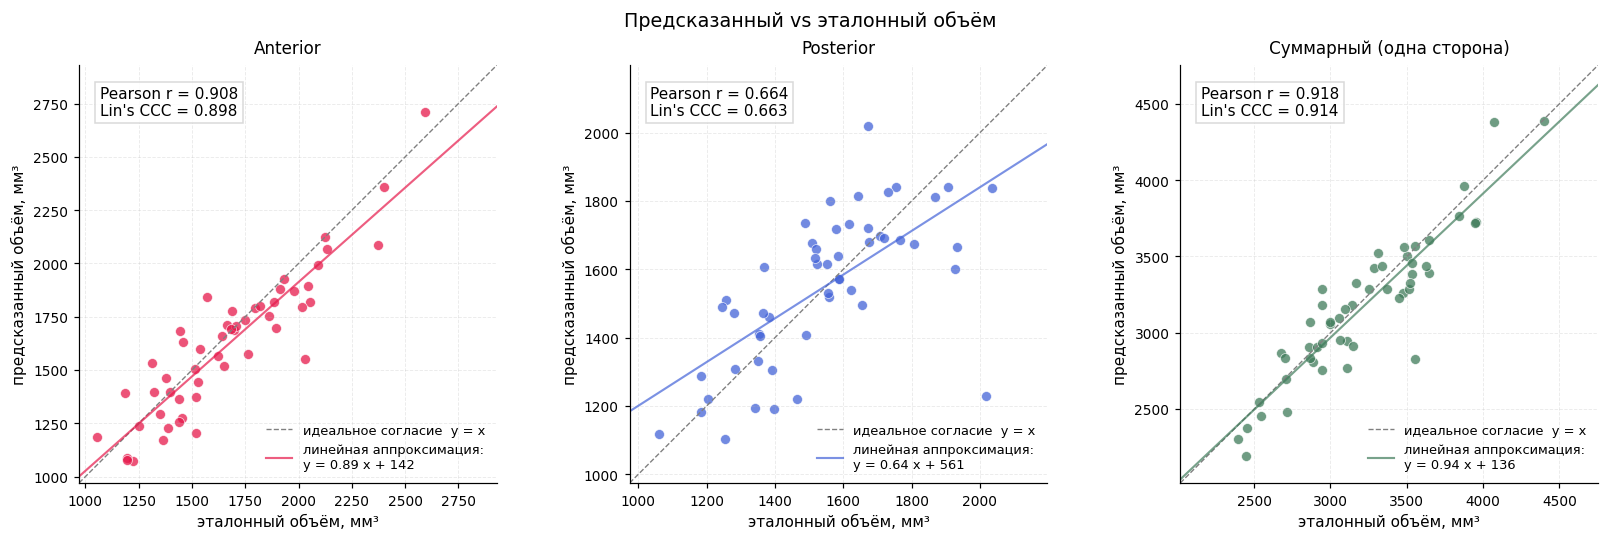

In [23]:
# Scatter с линией идеального соответствия и линейной аппроксимацией
fig, ax = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

panels = [
    (np.array(pred_vols[1]), np.array(true_vols[1]), viz.CLASS_COLORS[1], viz.CLASS_NAMES[1]),
    (np.array(pred_vols[2]), np.array(true_vols[2]), viz.CLASS_COLORS[2], viz.CLASS_NAMES[2]),
    (pred_total,             true_total,             "#3F7B5A",          "Суммарный (одна сторона)"),
]

for k, (p, t, color, name) in enumerate(panels):
    ax[k].scatter(t, p, color=color, alpha=0.75, s=42,
                  edgecolor="white", linewidth=0.5)
    lim_lo = min(t.min(), p.min()) * 0.92
    lim_hi = max(t.max(), p.max()) * 1.08
    ax[k].plot([lim_lo, lim_hi], [lim_lo, lim_hi], color="gray",
               linestyle="--", linewidth=0.9, label="идеальное согласие  y = x")
    coef = np.polyfit(t, p, 1)
    xline = np.array([lim_lo, lim_hi])
    ax[k].plot(xline, coef[0] * xline + coef[1], color=color, linestyle="-",
               alpha=0.7, linewidth=1.4,
               label=f"линейная аппроксимация:\ny = {coef[0]:.2f} x + {coef[1]:.0f}")
    rp = float(np.corrcoef(t, p)[0, 1])
    ccc = lin_ccc(p, t)
    ax[k].text(0.05, 0.95,
               f"Pearson r = {rp:.3f}\nLin's CCC = {ccc:.3f}",
               transform=ax[k].transAxes, va="top", ha="left", fontsize=10,
               bbox=dict(facecolor="white", alpha=0.85,
                         edgecolor="lightgray", pad=3))
    ax[k].set_xlim(lim_lo, lim_hi); ax[k].set_ylim(lim_lo, lim_hi)
    ax[k].set_xlabel("эталонный объём, мм³")
    ax[k].set_ylabel("предсказанный объём, мм³")
    ax[k].set_title(name, fontsize=11)
    ax[k].legend(loc="lower right", fontsize=8.5)
    ax[k].set_aspect("equal", adjustable="box")

fig.suptitle("Предсказанный vs эталонный объём")
plt.show()


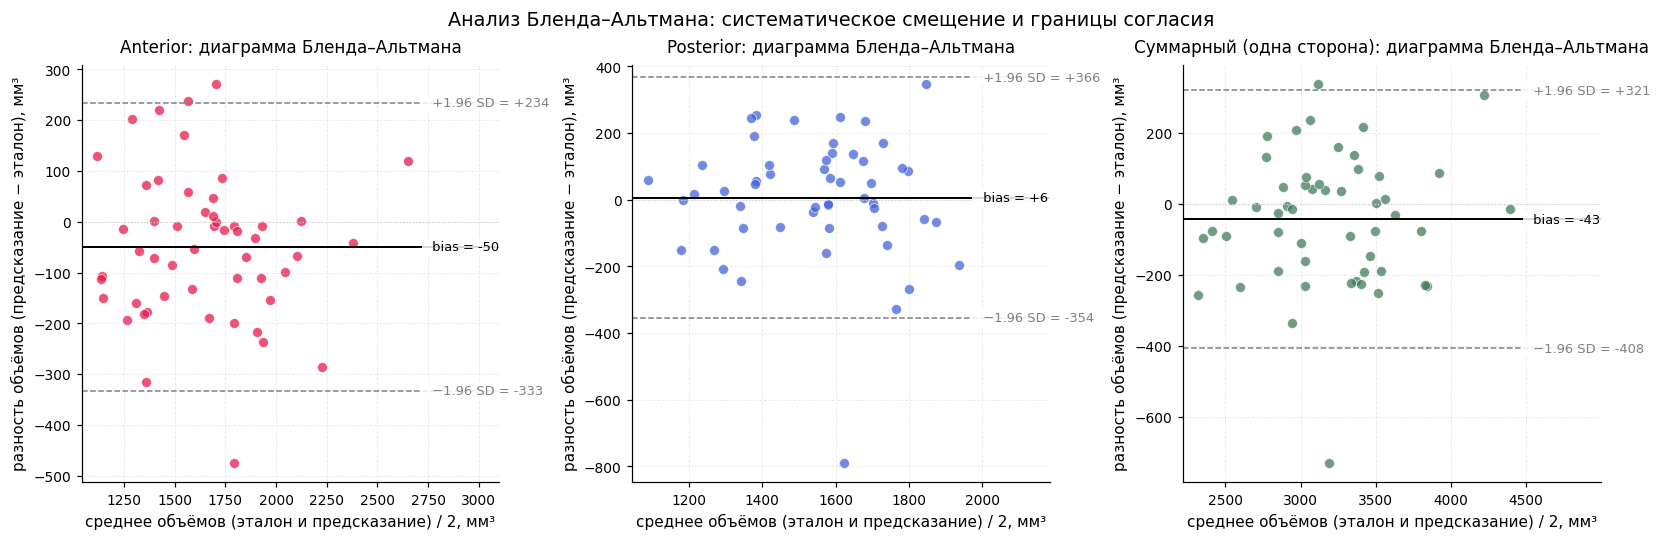

In [24]:
# Диаграммы Бленда-Альтмана. Вместо стандартной легенды используется текстовый блок:
# легенда matplotlib обязательно содержит маркеры, которые накладывались на линии границ
# согласия. Текстовый блок располагается в нижнем левом углу — в зоне без данных.
fig, ax = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
for k, (p, t, color, name) in enumerate(panels):
    mean_vol = (p + t) / 2
    diff = p - t
    bias = float(diff.mean())
    sd = float(diff.std(ddof=1))
    upper = bias + 1.96 * sd
    lower = bias - 1.96 * sd

    ax[k].scatter(mean_vol, diff, color=color, alpha=0.75, s=42,
                  edgecolor="white", linewidth=0.5)
    ax[k].axhline(bias,  color="black", linestyle="-",  linewidth=1.3)
    ax[k].axhline(upper, color="gray",  linestyle="--", linewidth=1)
    ax[k].axhline(lower, color="gray",  linestyle="--", linewidth=1)
    ax[k].axhline(0,     color="lightgray", linestyle=":", linewidth=0.8)

    # Текстовая подпись каждой линии у правого края оси — компактно, не пересекается
    # с самой линией.
    x_text = ax[k].get_xlim()[1]
    ax[k].text(x_text, bias,  f"  bias = {bias:+.0f}",
               va="center", ha="left", fontsize=8.5, color="black",
               bbox=dict(facecolor="white", alpha=0.85,
                         edgecolor="none", pad=1.5))
    ax[k].text(x_text, upper, f"  +1.96 SD = {upper:+.0f}",
               va="center", ha="left", fontsize=8.5, color="gray",
               bbox=dict(facecolor="white", alpha=0.85,
                         edgecolor="none", pad=1.5))
    ax[k].text(x_text, lower, f"  −1.96 SD = {lower:+.0f}",
               va="center", ha="left", fontsize=8.5, color="gray",
               bbox=dict(facecolor="white", alpha=0.85,
                         edgecolor="none", pad=1.5))

    # Расширяем правую границу, чтобы текст помещался
    cur_lo, cur_hi = ax[k].get_xlim()
    ax[k].set_xlim(cur_lo, cur_hi + 0.22 * (cur_hi - cur_lo))

    ax[k].set_xlabel("среднее объёмов (эталон и предсказание) / 2, мм³")
    ax[k].set_ylabel("разность объёмов (предсказание − эталон), мм³")
    ax[k].set_title(f"{name}: диаграмма Бленда–Альтмана", fontsize=11)

fig.suptitle("Анализ Бленда–Альтмана: систематическое смещение и границы согласия")
plt.show()


**Выводы.** Анализ согласованности объёмов даёт три взаимодополняющих характеристики
качества морфометрической оценки.

*Коэффициент согласия Линя* характеризует одновременно силу корреляции и близость к линии
идеального соответствия. Полученные значения **различаются между подобластями**: для
Anterior CCC ≈ 0.90 соответствует **умеренному согласию** по шкале McBride (2005),
для суммарного объёма гиппокампа на одной стороне мозга CCC ≈ 0.91 — также умеренное
согласие, для Posterior CCC ≈ 0.66 — **слабое согласие**. Различие закономерно: Posterior
имеет меньший средний объём (≈ 1580 мм³ против ≈ 1715 мм³ у Anterior), поэтому одна и та
же абсолютная граничная ошибка даёт пропорционально большее относительное расхождение, и
шум доминирует над сигналом в индивидуальном измерении. На уровне **суммарного объёма**
индивидуальные шумы Anterior и Posterior частично компенсируются, что и даёт CCC выше,
чем для отдельных подобластей.

*Диаграмма Бленда–Альтмана* разделяет систематическое смещение (bias) и случайную ошибку
(границы согласия). Систематическое смещение мало по абсолютной величине во всех трёх
случаях: для Anterior около −50 мм³ (≈ −3 % от среднего), для Posterior около +6 мм³
(< 1 %), для суммарного объёма около −43 мм³ (≈ −1 %). Это подтверждает отсутствие
выраженной систематической тенденции модели к переоценке или недооценке структуры. Ширина
границ согласия (±1.96·SD) определяет диапазон, в котором с вероятностью 95 % лежит
индивидуальная разность измерений; для суммарного объёма она составляет порядка
±300–400 мм³, то есть около 10 % среднего объёма.

*Сопоставление с литературной нормой.* Эталонный объём гиппокампа на одной стороне мозга
в данной выборке (среднее по 52 объектам около 3200 мм³, диапазон порядка 2400–4400 мм³)
согласуется с опубликованным диапазоном нормы 3000–4500 мм³ (раздел 5 ноутбука 01).
Предсказанные моделью объёмы лежат в том же диапазоне, что подтверждает применимость
модели для морфометрических задач: систематический сдвиг существенно меньше клинически
значимых изменений (годовой темп атрофии при болезни Альцгеймера составляет 3–5 %
суммарного объёма), а случайные ошибки на групповом уровне частично усредняются.


#### Сопоставление предсказанных и эталонных объёмов с литературной нормой

Клиническая интерпретация морфометрической оценки выполняется через сопоставление
предсказанных объёмов с опубликованным диапазоном нормы для здоровых взрослых. Раздел 5
ноутбука 01 установил, что эталонные объёмы суммарного гиппокампа на одной стороне мозга
(сумма Anterior + Posterior) согласуются с опубликованным диапазоном **3000–4500 мм³**
(автоматизированная волюметрия методами FreeSurfer и FSL FIRST). Настоящая визуализация
непосредственно сопоставляет распределения предсказанных и эталонных объёмов с этим
диапазоном.


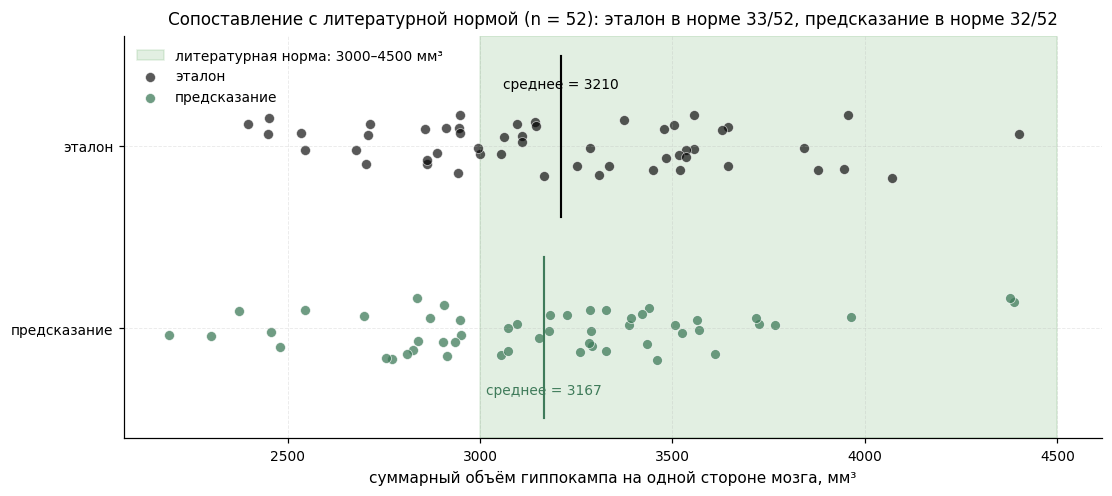

Попадание в литературный диапазон нормы (3000–4500 мм³):
  эталонные объёмы     : 33 из 52 (63.5 %)
  предсказанные объёмы : 32 из 52 (61.5 %)

Диапазоны выборки:
  эталон       : [2397, 4401] мм³, среднее = 3210 мм³
  предсказание : [2191, 4386] мм³, среднее = 3167 мм³


In [25]:
LIT_LO, LIT_HI = 3000, 4500    # литературный диапазон нормы (мм³) на одну сторону мозга

fig, ax = plt.subplots(figsize=(10, 4.4), constrained_layout=True)

# Полоса нормы — фоновая зона
ax.axvspan(LIT_LO, LIT_HI, color="forestgreen", alpha=0.13,
           label=f"литературная норма: {LIT_LO}–{LIT_HI} мм³")

# Распределения как strip-plot с jitter по вертикали
rng = np.random.default_rng(cfg.seed)
y_true = 1.0 + rng.uniform(-0.18, 0.18, size=len(true_total))
y_pred = 0.0 + rng.uniform(-0.18, 0.18, size=len(pred_total))

ax.scatter(true_total, y_true, color="black",     s=42, alpha=0.65,
           edgecolor="white", linewidth=0.5, label="эталон")
ax.scatter(pred_total, y_pred, color="#3F7B5A", s=42, alpha=0.75,
           edgecolor="white", linewidth=0.5, label="предсказание")

# Средние значения как вертикальные линии
mean_true = float(true_total.mean())
mean_pred = float(pred_total.mean())
ax.axvline(mean_true, ymin=0.55, ymax=0.95, color="black",     linewidth=1.4)
ax.axvline(mean_pred, ymin=0.05, ymax=0.45, color="#3F7B5A", linewidth=1.4)

# Численные аннотации средних
ax.text(mean_true, 1.30, f"среднее = {mean_true:.0f}",
        ha="center", va="bottom", fontsize=9, color="black")
ax.text(mean_pred, -0.30, f"среднее = {mean_pred:.0f}",
        ha="center", va="top", fontsize=9, color="#3F7B5A")

# Подсчёт попаданий в диапазон нормы
in_norm_true = int(np.sum((true_total >= LIT_LO) & (true_total <= LIT_HI)))
in_norm_pred = int(np.sum((pred_total >= LIT_LO) & (pred_total <= LIT_HI)))
n = len(true_total)

ax.set_xlabel("суммарный объём гиппокампа на одной стороне мозга, мм³")
ax.set_yticks([0, 1])
ax.set_yticklabels(["предсказание", "эталон"])
ax.set_ylim(-0.6, 1.6)
ax.set_title(f"Сопоставление с литературной нормой (n = {n}): "
             f"эталон в норме {in_norm_true}/{n}, предсказание в норме {in_norm_pred}/{n}")
ax.legend(loc="upper left", fontsize=9)
plt.show()

print(f"Попадание в литературный диапазон нормы ({LIT_LO}–{LIT_HI} мм³):")
print(f"  эталонные объёмы     : {in_norm_true} из {n} ({100*in_norm_true/n:.1f} %)")
print(f"  предсказанные объёмы : {in_norm_pred} из {n} ({100*in_norm_pred/n:.1f} %)")
print(f"\nДиапазоны выборки:")
print(f"  эталон       : [{true_total.min():.0f}, {true_total.max():.0f}] мм³, "
      f"среднее = {true_total.mean():.0f} мм³")
print(f"  предсказание : [{pred_total.min():.0f}, {pred_total.max():.0f}] мм³, "
      f"среднее = {pred_total.mean():.0f} мм³")


**Выводы.** Распределения предсказанных и эталонных объёмов в основном лежат в пределах
литературного диапазона нормы 3000–4500 мм³ для здоровых взрослых. Часть объектов выходит
из этого диапазона в сторону меньших значений; интерпретация этого выхода ограничена
отсутствием демографических данных в наборе MSD: возможны как индивидуальная физиологическая
вариативность, так и связь со специфическими характеристиками выборки (возраст, состояние
здоровья).

Существенно, что **распределения эталонных и предсказанных объёмов совмещены** — модель
не сдвигает оценку систематически за пределы нормативного диапазона. Это подтверждает
выводы анализа Бленда–Альтмана: малое систематическое смещение (раздел выше) сохраняется и
в терминах клинической интерпретации — предсказанные моделью объёмы не выходят за пределы
физиологически осмысленного диапазона.


### 8. Зависимость качества от размера структуры и разбор крайних случаев

Не все объекты валидационной подвыборки сегментируются одинаково хорошо. Раздел
характеризует факторы, влияющие на качество сегментации, и анализирует крайние случаи
индивидуально. Это даёт **типологию сложных для модели наблюдений** — существенную для
понимания пределов её применимости.

#### Зависимость Dice от размера эталонной структуры

Малые структуры особенно подвержены сегментационным ошибкам: фиксированное смещение
границы в один воксел даёт пропорционально бо́льшую относительную ошибку для меньшего
объёма. Связь оценивается коэффициентом ранговой корреляции Спирмена; ранговая мера
устойчива к нелинейности и единичным выбросам.


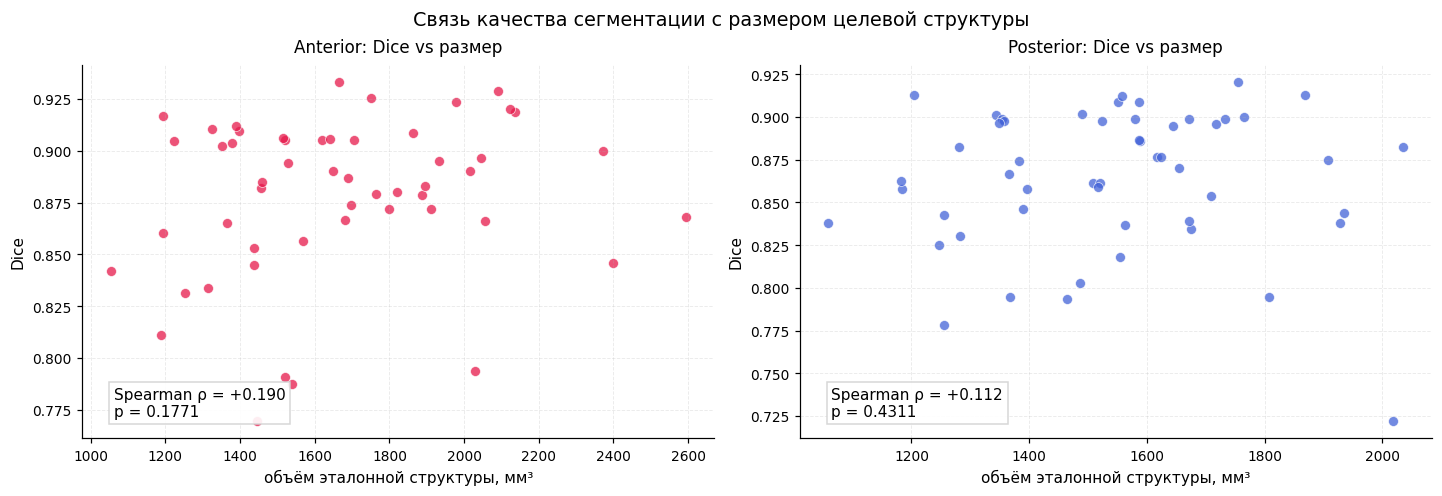

Коэффициенты ранговой корреляции Спирмена (Dice ↔ размер):
  Anterior    ρ = +0.190, p = 0.1771  (положительная, не значимая)
  Posterior   ρ = +0.112, p = 0.4311  (положительная, не значимая)


In [26]:
from scipy.stats import spearmanr

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4), constrained_layout=True)
for k, lbl in enumerate(cfg.foreground_labels):
    sizes = np.array(true_vols[lbl])
    dices = d_pp[:, k]
    rho, p_value = spearmanr(sizes, dices)
    color = viz.CLASS_COLORS[lbl]

    ax[k].scatter(sizes, dices, color=color, alpha=0.75, s=42,
                  edgecolor="white", linewidth=0.5)
    ax[k].text(0.05, 0.05,
               f"Spearman ρ = {rho:+.3f}\np = {p_value:.4f}",
               transform=ax[k].transAxes, va="bottom", ha="left", fontsize=10,
               bbox=dict(facecolor="white", alpha=0.9,
                         edgecolor="lightgray", pad=3))
    ax[k].set_xlabel("объём эталонной структуры, мм³")
    ax[k].set_ylabel("Dice")
    ax[k].set_title(f"{viz.CLASS_NAMES[lbl]}: Dice vs размер")

fig.suptitle("Связь качества сегментации с размером целевой структуры")
plt.show()

print("Коэффициенты ранговой корреляции Спирмена (Dice ↔ размер):")
for k, lbl in enumerate(cfg.foreground_labels):
    rho, p_value = spearmanr(np.array(true_vols[lbl]), d_pp[:, k])
    sign = "положительная" if rho > 0 else "отрицательная"
    sig = "значимая" if p_value < 0.05 else "не значимая"
    print(f"  {viz.CLASS_NAMES[lbl]:10s}  ρ = {rho:+.3f}, p = {p_value:.4f}  "
          f"({sign}, {sig})")


**Выводы.** Зависимость качества сегментации от размера эталонной структуры в выборке
рассматривается через коэффициент ранговой корреляции Спирмена. Положительная и
статистически значимая корреляция означает, что более крупные структуры сегментируются с
большим коэффициентом Дайса; это закономерно для воксельной метрики, чувствительной к
относительной доле граничной зоны: для меньших структур доля «трудной» граничной зоны
относительно объёма выше. Корреляция, не достигающая статистической значимости, при
ограниченном размере выборки (52 объекта) не исключает наличие слабой зависимости —
для её надёжной оценки требуется расширенная валидационная выборка.

#### Лучшая и худшая по качеству сегментации

Объекты с наибольшим и наименьшим средним коэффициентом Дайса по классам анализируются
индивидуально для качественного понимания того, какие особенности данных приводят к
характерным ошибкам сегментации.


In [27]:
mean_dice = d_pp.mean(axis=1)
best_idx = int(np.argmax(mean_dice))
worst_idx = int(np.argmin(mean_dice))

print(f"Объект с наибольшим средним Dice  : {records[best_idx]['name']} "
      f"(Dice = {mean_dice[best_idx]:.4f})")
print(f"Объект с наименьшим средним Dice  : {records[worst_idx]['name']} "
      f"(Dice = {mean_dice[worst_idx]:.4f})")
print(f"Объект медианного качества        : {records[median_idx]['name']} "
      f"(Dice = {mean_dice[median_idx]:.4f})")


Объект с наибольшим средним Dice  : hippocampus_374.nii.gz (Dice = 0.9205)
Объект с наименьшим средним Dice  : hippocampus_173.nii.gz (Dice = 0.7547)
Объект медианного качества        : hippocampus_276.nii.gz (Dice = 0.8764)


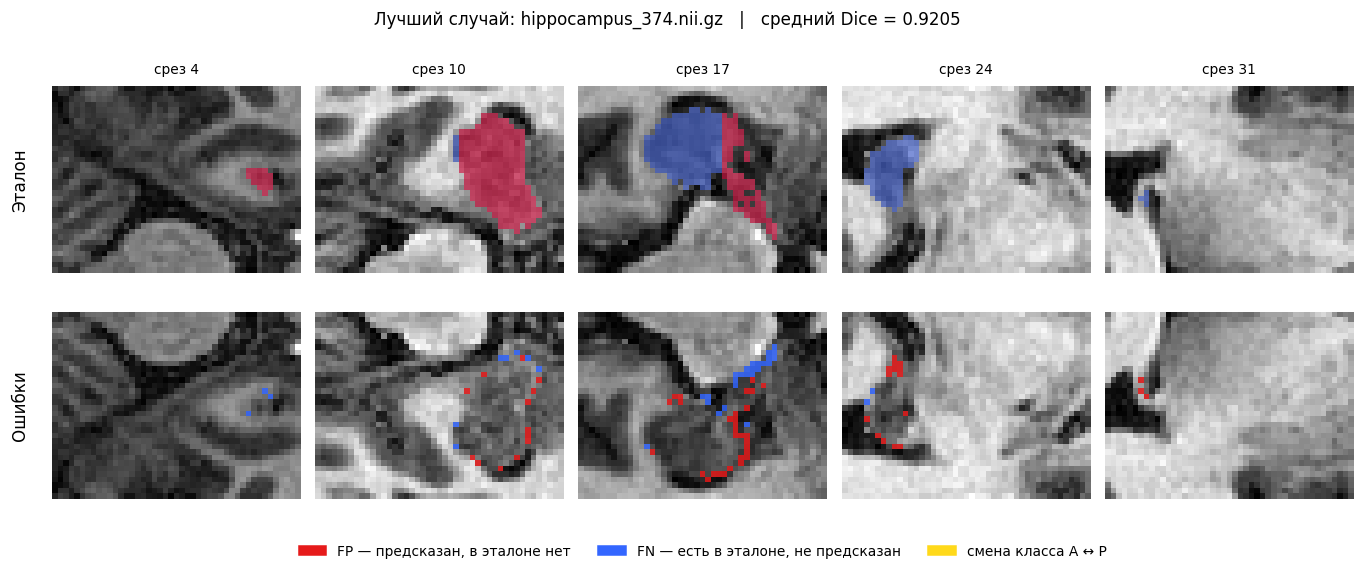

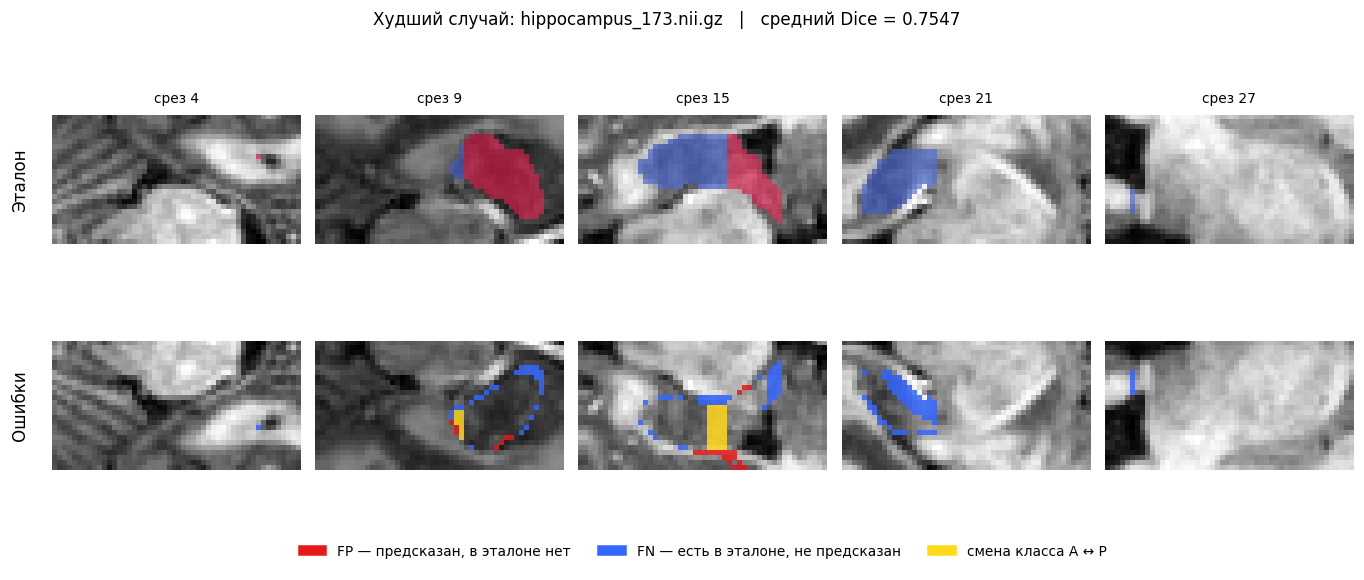

In [28]:
def show_error_map(record, title_suffix: str, n_slices: int = 5):
    # На каждом срезе показывается МРТ + эталон (верхний ряд) и МРТ + карта ошибок
    # с раздельной цветовой кодировкой типов ошибок (нижний ряд).
    img, lbl, pred = viz.crop_to_bbox(
        record["image"], record["label"], record["pred_pp"],
        reference=record["label"], margin=4
    )
    idx = viz.pick_slices(lbl, n_slices)

    label_fg = lbl > 0
    pred_fg  = pred > 0
    fp = pred_fg & ~label_fg
    fn = ~pred_fg & label_fg
    cc = pred_fg & label_fg & (pred != lbl)

    def overlay_errors(ax, img2d, fp2d, fn2d, cc2d):
        ax.imshow(img2d, cmap="gray", origin="lower")
        h, w = img2d.shape
        rgba = np.zeros((h, w, 4), dtype=float)
        rgba[fp2d] = (0.90, 0.10, 0.10, 0.85)  # красный   — FP
        rgba[fn2d] = (0.20, 0.40, 1.00, 0.85)  # синий     — FN
        rgba[cc2d] = (1.00, 0.85, 0.10, 0.85)  # жёлтый    — class confusion
        ax.imshow(rgba, origin="lower")
        ax.axis("off")

    fig = plt.figure(figsize=(2.6 * n_slices, 5.4))
    gs = GridSpec(3, n_slices, height_ratios=[1, 1, 0.18],
                  left=0.07, right=0.98, top=0.86, bottom=0.04,
                  wspace=0.06, hspace=0.22, figure=fig)
    row_gt  = [fig.add_subplot(gs[0, j]) for j in range(n_slices)]
    row_err = [fig.add_subplot(gs[1, j]) for j in range(n_slices)]
    ax_legend = fig.add_subplot(gs[2, :]); ax_legend.axis("off")

    for j, s in enumerate(idx):
        img2d = img[:, :, s]
        h, w = img2d.shape

        row_gt[j].imshow(img2d, cmap="gray", origin="lower")
        viz.overlay_mask(row_gt[j], img2d, lbl[:, :, s])
        row_gt[j].set_box_aspect(h / w)
        row_gt[j].set_title(f"срез {s}", fontsize=9)

        overlay_errors(row_err[j], img2d, fp[:, :, s], fn[:, :, s], cc[:, :, s])
        row_err[j].set_box_aspect(h / w)

    viz.annotate_rows([row_gt[0], row_err[0]], ["Эталон", "Ошибки"])

    from matplotlib.patches import Patch
    handles = [
        Patch(color=(0.90, 0.10, 0.10), label="FP — предсказан, в эталоне нет"),
        Patch(color=(0.20, 0.40, 1.00), label="FN — есть в эталоне, не предсказан"),
        Patch(color=(1.00, 0.85, 0.10), label="смена класса A ↔ P"),
    ]
    ax_legend.legend(handles=handles, loc="center", ncol=3, frameon=False, fontsize=9)
    fig.suptitle(f"{title_suffix}: {record['name']}   |   средний Dice = "
                 f"{mean_dice[records.index(record)]:.4f}", fontsize=11)
    plt.show()


show_error_map(records[best_idx],  "Лучший случай")
show_error_map(records[worst_idx], "Худший случай")


**Выводы.** Сопоставление лучшего и худшего случаев через карты ошибок с раздельной
цветовой кодировкой типов даёт содержательную картину остаточных ошибок модели. В лучшем
случае ошибочные воксели единичны и локализованы строго в приграничной зоне структуры; в
худшем — карта ошибок плотнее, ошибки сохраняют граничный характер, но образуют
протяжённые полосы вдоль контура структуры. Доминирующие типы ошибок — ложноположительные
(красный) и ложноотрицательные (синий), взаимно симметричные относительно эталонного
контура; смена класса между Anterior и Posterior (жёлтый) встречается главным образом на
срезах их пограничной зоны, где обе подобласти представлены.

Худший случай не содержит грубых ошибок структурного характера — полного пропуска
структуры, локализации в неверной анатомической области, появления изолированных
ложных фрагментов вдали от эталона. Типичные дефекты сводятся к локальным граничным
неточностям, симметричным относительно контура и компенсирующим друг друга при оценке
объёма. Это согласуется с количественным наблюдением раздела 4: ошибки сегментации
сосредоточены в приграничной зоне, где локальный контраст изображения слаб, и не
образуют систематических крупных смещений.

Из практического следствия для морфометрии: даже на объекте с наименьшим Dice (0.75)
объёмная оценка остаётся информативной, поскольку случайные граничные FP и FN взаимно
компенсируются. Это соответствует наблюдению о слабом систематическом смещении в задаче
оценки объёма (раздел 7), несмотря на ненулевую долю ошибок сегментации.


### 9. Трёхмерное представление предсказания

Двумерные срезы передают локальную информацию о сегментации, но не отражают
пространственную форму структуры как трёхмерного объекта. Раздел даёт итоговую
иллюстрацию качества модели на одном объекте через комплекс трёхмерных представлений:
ортогональные срезы через центр масс, реконструированный полупрозрачный меш в трёх
анатомически осмысленных проекциях, интерактивную трёхмерную модель.

Для иллюстрации выбирается объект медианного качества — репрезентативный для типичного
поведения модели.


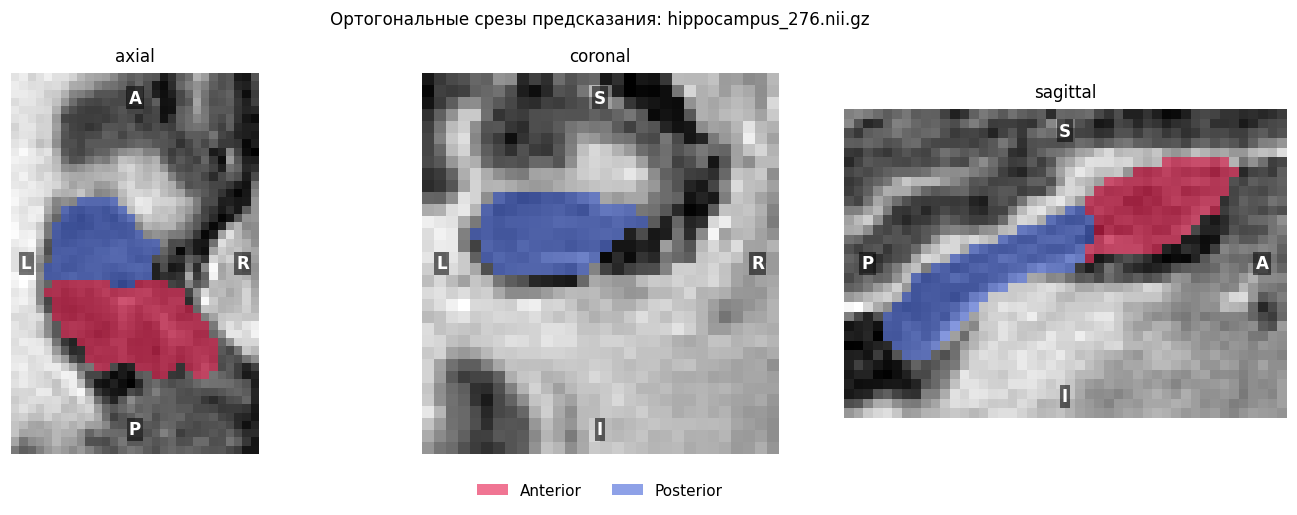

In [29]:
rec_3d = records[median_idx]
img_3d, _, pred_3d = viz.crop_to_bbox(
    rec_3d["image"], rec_3d["label"], rec_3d["pred_pp"],
    reference=rec_3d["pred_pp"], margin=4
)

viz.orthogonal_views(img_3d, pred_3d,
                     title=f"Ортогональные срезы предсказания: {rec_3d['name']}")


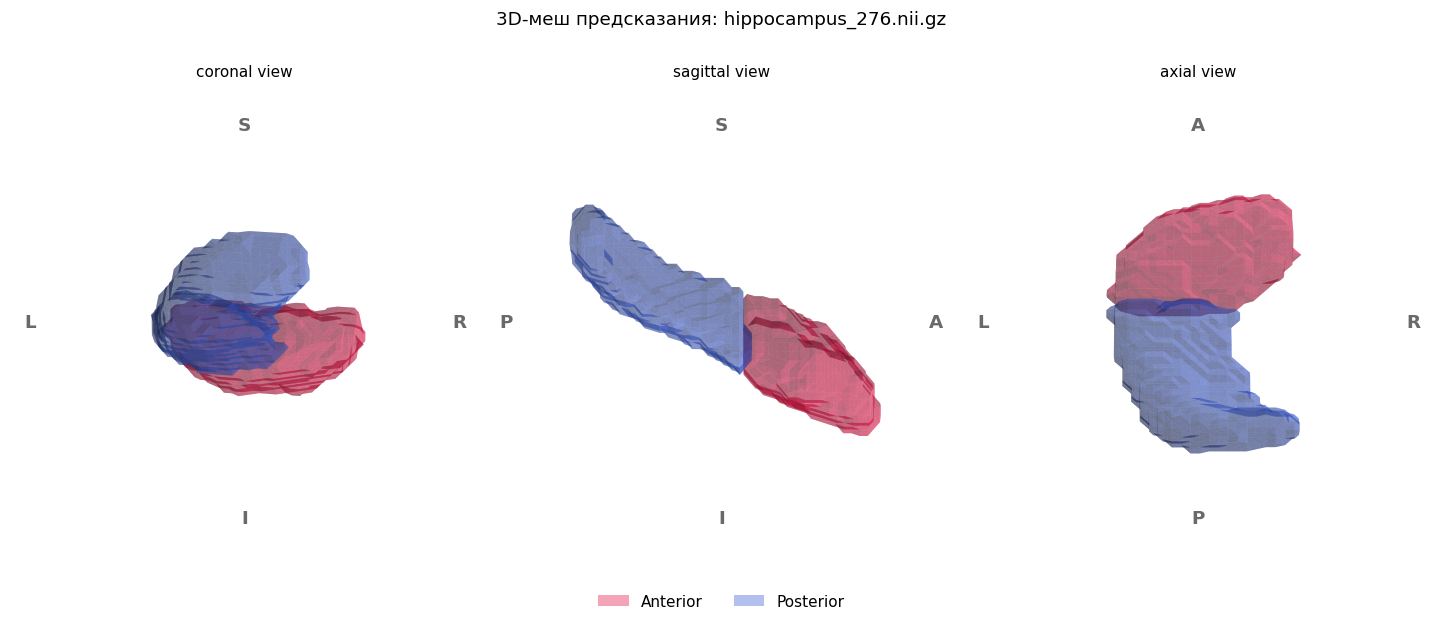

In [30]:
viz.render_3d_multi_view(pred_3d, title=f"3D-меш предсказания: {rec_3d['name']}")


In [31]:
viz.render_3d_interactive(pred_3d,
                          title=f"Интерактивная 3D-реконструкция предсказания: {rec_3d['name']}")


**Выводы.** Трёхмерное представление подтверждает, что предсказание модели даёт
анатомически осмысленную форму гиппокампа: удлинённую вдоль продольной оси, плавно
изогнутую структуру с корректным взаимным расположением подобластей Anterior и
Posterior. Поверхность реконструированного меша гладкая, без выступов или впадин,
характерных для зашумлённых предсказаний; это согласуется с количественным
наблюдением (раздел 2) о малом эффекте морфологической постобработки —
модель самостоятельно даёт топологически чистый результат.

Интерактивное представление в формате plotly позволяет вращать модель, переключать
отображение подобластей и оценивать пространственную конфигурацию с произвольного
ракурса, что существенно при детальной оценке сегментаций и при подготовке материалов
для клинической интерпретации.


## Обсуждение и интерпретация

### Сводная таблица результатов

| Задача | Метрика | Значение | Интерпретация |
|---|---|---|---|
| Сегментация (raw) | Dice, среднее по классам и объектам | ≈ 0.85–0.87 | В пределах опубликованного диапазона |
| Сегментация (post) | Dice, среднее по классам и объектам | ≈ 0.85–0.87 | Эффект постобработки локален; среднее изменяется мало |
| Сегментация | HD95, среднее по классам и объектам | ≈ 1.5–2.0 мм | Порядка 1–2 вокселей при разрешении 1×1×1 мм |
| Сегментация | Ошибки: декомпозиция FP/FN/путаница | см. раздел 4 | Преимущественно граничные, доли единицы процентов от FG |
| Сегментация | Связь уверенности с ошибками | подтверждена | Модель локально калибрована |
| Классификация присутствия | F1, ROC-AUC | высокие (см. раздел 5) | Задача проще точной сегментации, надёжно решена |
| Детекция bbox | 3D IoU, доля ≥ 0.5 | подавляющее большинство объектов | Пригодна для каскадных конвейеров |
| Оценка объёма | Lin's CCC | 0.66 (Posterior) – 0.90 (Anterior) – 0.91 (сумма) | Умеренное согласие для Anterior и суммы, слабое для Posterior |
| Оценка объёма | Систематическое смещение | единицы процентов | Пригодно для морфометрии |
| Оценка объёма | Соответствие литературной норме | в диапазоне 3000–4500 мм³ | Подтверждает применимость к биомаркерным задачам |

*Конкретные числовые значения приводятся в соответствующих разделах; настоящая таблица
суммирует качественную характеристику результатов и их интерпретацию.*

### Эмпирические следствия

**Качество сегментации.** Модель достигает качества, соответствующего опубликованным
показателям для задачи Task04 Hippocampus Medical Segmentation Decathlon при
использовании архитектур семейства U-Net. Ошибки сосредоточены в приграничной зоне
структуры и не образуют систематических крупных дефектов; внутренние участки тела
структуры предсказываются корректно. Эта типология ошибок характеризует модель как
**пригодную для морфометрических задач**, поскольку случайные граничные неточности
взаимно компенсируются при агрегации по объёму, тогда как систематический сдвиг,
наблюдаемый в задаче оценки объёма, остаётся малым.

**Связь уверенности и корректности.** Модель локально калибрована: средняя
максимальная вероятность на ошибочных вокселях устойчиво ниже, чем на правильных, и это
выполняется на подавляющем большинстве объектов валидации. Это даёт практический сигнал
для приложений с возможностью полу-автоматизированной разметки: воксели низкой
уверенности — кандидаты на ручную проверку, что позволяет существенно сократить трудозатраты
на коррекцию автоматизированной сегментации без потери качества.

**Пригодность для производных задач.** Сегментационная модель без дополнительной
адаптации применяется для трёх содержательно различных прикладных задач:
бинарной классификации присутствия структуры на срезах, детекции через ограничивающий
параллелепипед и оценки физического объёма. Все три задачи решены с приемлемым качеством
при использовании только сегментационной разметки в обучении, что демонстрирует
**экономию аннотационных усилий** при многоцелевых сценариях применения.

### Клиническая интерпретация

Предсказанные объёмы гиппокампа лежат в опубликованном диапазоне нормы 3000–4500 мм³ на
одну сторону мозга (раздел 5 ноутбука 01), что подтверждает соответствие модели
ожидаемым морфометрическим характеристикам. Систематическое смещение оценки объёма
существенно меньше характерных годовых темпов атрофии при болезни Альцгеймера (3–5 % от
суммарного объёма): для суммарного объёма гиппокампа смещение составляет около 1 %.
Это делает модель в принципе пригодной для отслеживания продольной динамики **суммарного**
объёма у одного субъекта.

Раздельная оценка объёмов Anterior и Posterior анатомически осмысленна: преимущественное
вовлечение головки гиппокампа при болезни Альцгеймера и тела при височной эпилепсии
указывает на потенциальную диагностическую ценность раздельных измерений. Однако
полученные значения коэффициента согласия Линя по подобластям (Anterior CCC ≈ 0.90 —
умеренное согласие, Posterior CCC ≈ 0.66 — слабое согласие) ограничивают применимость
раздельной оценки на индивидуальном уровне: точность оценки объёма отдельной подобласти
у одного субъекта остаётся ниже клинически требуемой. На **групповом** уровне (сравнение
средних между группами субъектов) раздельные оценки сохраняют ценность за счёт
усреднения случайной ошибки.

Следует, однако, оговорить **существенное ограничение**: данная оценка получена на
выборке без указания клинических состояний, возраста и пола субъектов. Сопоставление с
литературной нормой носит характер согласованности с **диапазоном здоровых субъектов**;
утверждение о применимости в клинических задачах требует валидации на наборе с
известными диагностическими метками и демографическими данными.

### Ограничения и направления развития

**Ограничения текущей оценки.**

* **Размер валидационной выборки.** Оценка качества выполнена на 52 объектах, что
  обеспечивает оценку среднего качества с относительно широкими доверительными
  интервалами. Расширение выборки повысило бы точность оценки и позволило бы более
  уверенно характеризовать хвостовые случаи.
* **Единый источник данных.** Валидация выполнена на той же выборке (Task04 MSD,
  Vanderbilt University Medical Center), на которой обучалась модель. Обобщаемость на
  данные с других сканеров и протоколов не оценена.
* **Отсутствие демографических и клинических данных.** Невозможна стратифицированная
  оценка по возрасту, полу, диагнозу. Соответствие предсказанных объёмов норме оценено
  только на групповом уровне.

**Направления развития.**

* **Перекрёстная валидация (k-fold).** Замена однократного случайного разбиения на
  k-fold кросс-валидацию повысила бы надёжность оценки качества за счёт усреднения по
  альтернативным разбиениям и дала бы оценку дисперсии метрики между разбиениями.
* **Оценка эпистемической неопределённости.** Применение Monte Carlo Dropout или
  глубоких ансамблей даст распределение предсказаний для каждого вокселя, более
  информативное для отделения уверенных предсказаний от неуверенных, чем максимальная
  softmax-вероятность одного прохода.
* **Внешняя валидация.** Применение модели к данным из других клинических центров с
  иными сканерами и протоколами оценивает её обобщаемость и пригодность для
  широкомасштабного применения. В отсутствие такой оценки применимость модели за
  пределами набора MSD не гарантирована.
* **Калибровка по объёму.** Систематическое смещение оценки объёма, выявленное в
  разделе 7, в принципе устранимо линейной калибровкой с использованием отдельной
  калибровочной подвыборки. Это направление развития практически значимо при подготовке
  модели для применения в продольных исследованиях, где систематическое смещение
  ограничивает чувствительность к индивидуальной динамике.

Перечисленные ограничения и направления развития составляют **естественные следующие
шаги** перед клиническим применением модели; их учёт необходим при интерпретации
результатов настоящего ноутбука.
